In [1]:
import gzip
import pickle 
import matplotlib
matplotlib.rc('font', size=15)
import torch 
import pandas as pd
import numpy as np
import plotly.express as px
import sys
sys.path.append("/afs/cern.ch/work/m/mgarciam/private/mlpf/")
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

/afs/cern.ch/work/m/mgarciam/private/miniconda/miniconda3/envs/graphgps0/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib
import sys
import os
from src.utils.inference.per_particle_metrics import plot_per_energy_resolution, reco_hist, \
    plot_mass_contribution_per_category, plot_mass_contribution_per_PID
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import mplhep as hep
from src.utils.inference.pandas_helpers import open_mlpf_dataframe, concat_with_batch_fix
from src.utils.inference.per_particle_metrics import (
    plot_per_energy_resolution2_multiple, plot_confusion_matrix, plot_confusion_matrix_pandora
    , calc_unit_circle_dist, plot_per_energy_resolution2, analyze_fakes, analyze_fakes_PID,
    plot_cm_per_energy, plot_fake_and_missed_energy_regions, quick_plot_mass,
    plot_cm_per_energy_on_overview
)
from src.utils.inference.efficiency_calc_and_plots import plot_efficiency_all
from src.utils.inference.track_cluster_eff_plots import plot_track_assignation_eval
from src.utils.inference.event_Ks import get_decay_type
import matplotlib.pyplot as plt
import torch
import pickle
from src.evaluation.refactor.preprocess import preprocess_dataframe, renumber_batch_idx
hep.style.use("CMS")
font = {'size': 10}
matplotlib.rc('font', **font)
import argparse

In [3]:
from src.utils.inference.pandas_helpers import open_mlpf_dataframe, concat_with_batch_fix
import os
from src.evaluation.refactor.preprocess import preprocess_dataframe, renumber_batch_idx
dir_top = "/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/"

sd_hgb2, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_all0_0_None.pt"), False, False)
sd_hgb2 = sd_hgb2 #concat_with_batch_fix([sd_hgb1, sd_hgb2, sd_hgb3])

sd_pandora2, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_all0_0_None_pandora.pt"), False, False)
sd_pandora2 = sd_pandora2 #concat_with_batch_fix([sd_pandora1, sd_pandora2, sd_pandora3])


sd_hgb2, sd_pandora2 = preprocess_dataframe(sd_hgb2, sd_pandora2, "")


In [143]:


PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")

dir_top = "/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/"

sd_hgb1, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_200_PIDsimple_v140000_0_None.pt"), False, False)
sd_hgb = sd_hgb1 #concat_with_batch_fix([sd_hgb1, sd_hgb2, sd_hgb3])

sd_pandora1, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/05_EPID_times1_9000_200_PIDsimple_v140000_0_None_pandora.pt"), False, False)
sd_pandora = sd_pandora1 #concat_with_batch_fix([sd_pandora1, sd_pandora2, sd_pandora3])

sd_hgb, sd_pandora = preprocess_dataframe(sd_hgb, sd_pandora, "")

mask = (sd_hgb.pred_pid_matched==4)*(sd_hgb.calibrated_E<1.5)
sd_hgb.loc[mask, "pred_pid_matched"]=1


In [3]:



PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")

dir_top = "/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/"

sd_hgb1, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/test_gun_um1000_0_None.pt"), False, False)
sd_hgb = sd_hgb1 #concat_with_batch_fix([sd_hgb1, sd_hgb2, sd_hgb3])

sd_pandora1, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/test_gun_um1000_0_None_pandora.pt"), False, False)
sd_pandora = sd_pandora1 #concat_with_batch_fix([sd_pandora1, sd_pandora2, sd_pandora3])

sd_hgb_gt1, _ = open_mlpf_dataframe(os.path.join(dir_top, "showers_df_evaluation/test_gun_um1000_0_None.pt"), False, False)
sd_hgb_gt = sd_hgb_gt1 #concat_with_batch_fix([sd_hgb_gt1, sd_hgb_gt2, sd_hgb_gt3])

sd_hgb, sd_pandora = preprocess_dataframe(sd_hgb, sd_pandora, "")

mask = (sd_hgb.pred_pid_matched==4)*(sd_hgb.calibrated_E<1.5)
sd_hgb.loc[mask, "pred_pid_matched"]=1


/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/pandas_helpers.py:56: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask = (~np.isnan(sd["pred_showers_E"])) * (~np.isnan(sd["reco_showers_E"]))
/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/pandas_helpers.py:56: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask = (~np.isnan(sd["pred_showers_E"])) * (~np.isnan(sd["reco_showers_E"]))
/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/pandas_helpers.py:56: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask = (~np.isnan(sd["pred_showers_E"])) * (~np.isnan(sd["reco_showers_E"]))
/tmp/mgarciam/ipykernel_2328056/3299715219.py:17: UserWarning: evaluating in Python space because the '*' operator is not

In [4]:
mask = sd_hgb.pred_pid_matched==1
sd_hgb.loc[mask, "calibrated_E"] =  np.sqrt((sd_hgb[mask]["calibrated_E"])**2+(1.3957018E-01**2))
mask = sd_hgb.pred_pid_matched==0
sd_hgb.loc[mask, "calibrated_E"] =  np.sqrt((sd_hgb[mask]["calibrated_E"])**2+(5.10998902E-04**2))

In [6]:
# Initialise dictionaries
calc_fakes = sd_pandora is not None
pandora = calc_fakes
from src.utils.inference.efficiency_calc_and_plots import create_eff_dic_pandora,create_eff_dic, limit_error_bars


fs = 15
font = {'size': fs}
matplotlib.rc('font', **font)
hep.style.use("CMS")
from src.evaluation.plots_paper_HitPF.plot_clustering import particles


In [ ]:

colors_list = ["#E36414", "#0F4C5C"] #"#0F4C5C", "#E36414",
def plot_error_bars(photons_dic, ax, add, i =0 ):
    energy = photons_dic["energy_eff_" + str(i)]
    eff = photons_dic["eff"+ add + "_" + str(i)]
    error_y = photons_dic["errors"+ add + "_" + str(i)]
    yerr_lower, yerr_upper = limit_error_bars(eff, np.array(error_y)/2, upper_limit=1)
    ax.errorbar(energy, eff ,yerr= [yerr_lower, yerr_upper], ecolor="#E36414",elinewidth=2,
    alpha=1,
    capsize=6,
    linestyle="none")

def plot_error_bars_pandora(photons_dic, ax, add, i =0 ):
    energy = photons_dic["energy_eff_p"]
    eff = photons_dic["eff_p"+add]
    error_y = photons_dic["errors_p"+add]
    yerr_lower, yerr_upper = limit_error_bars(eff, np.array(error_y)/2, upper_limit=1)
    ax.errorbar(energy, eff ,yerr= [yerr_lower, yerr_upper], ecolor="#0F4C5C",elinewidth=2,
    alpha=1,
    capsize=6,
    linestyle="none")
def pot_error_bar_fakes(photons_dic, ax, i=0):
    energy = photons_dic["energy_fakes_" + str(i)]
    eff = photons_dic["fakes_" + str(i)]
    error_y = photons_dic["fakes_errors"+ str(i)]
    # yerr_lower, yerr_upper = limit_error_bars(eff, np.array(error_y)/2, upper_limit=1)
    error_y = np.array(error_y)/2
    ax.errorbar(energy, eff ,yerr= [error_y, error_y], ecolor="#E36414",elinewidth=2,
    alpha=1,
    capsize=6,
    linestyle="none")
def pot_error_bar_fakes_pandora(photons_dic, ax, i=0):
    energy = photons_dic["energy_fakes_p"]
    eff = photons_dic["fakes_p"]
    error_y = photons_dic["fakes_errors_p"]
    # yerr_lower, yerr_upper = limit_error_bars(eff, np.array(error_y)/2, upper_limit=1)
    error_y = np.array(error_y)/2
    ax.errorbar(energy, eff ,yerr= [error_y, error_y], ecolor="#0F4C5C",elinewidth=2,
    alpha=1,
    capsize=6,
    linestyle="none")



In [38]:
def pot_error_bar_fakes(
    photons_dic,
    ax,
    i=0,
    facecolor="#E36414",
    alpha=0.6,
    edgecolor=None,
):
    bins = np.exp(np.arange(np.log(0.1), np.log(80), 0.3))
    bins = bins
    eff = photons_dic["fakes_" + str(i)]
    error_y = photons_dic["fakes_errors"+ str(i)]
    # yerr_lower, yerr_upper = limit_error_bars(eff, np.array(error_y)/2, upper_limit=1)
    error_y = np.array(error_y)/2
    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - error_y[j]
        height = error_y[j] + error_y[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)

    # Optional: center markers
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    # ax.plot(bin_centers, eff, "o", color=facecolor)

def pot_error_bar_fakes_pandora(
    photons_dic,
    ax,
    i=0,
    facecolor="#0F4C5C",
    alpha=0.6,
    edgecolor=None,
):
    bins = np.exp(np.arange(np.log(0.1), np.log(80), 0.3))
    bins= bins
    energy = photons_dic["energy_fakes_p"]
    eff = photons_dic["fakes_p"]
    error_y = photons_dic["fakes_errors_p"]
    # yerr_lower, yerr_upper = limit_error_bars(eff, np.array(error_y)/2, upper_limit=1)
    error_y = np.array(error_y)/2

    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - error_y[j]
        height = error_y[j] + error_y[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)

In [32]:
from matplotlib.patches import Rectangle
def plot_error_bars(
    photons_dic,
    ax,
    add,
    i=0,
    facecolor="#E36414",
    alpha=0.6,
    edgecolor=None,
):
    bins = np.exp(np.arange(np.log(0.1), np.log(80), 0.3))
    bins = bins
    eff = photons_dic["eff" + add + "_" + str(i)][:-1]
    error_y = np.array(photons_dic["errors" + add + "_" + str(i)])[:-1]

    yerr_lower, yerr_upper = limit_error_bars(
        eff, error_y / 2, upper_limit=1
    )

    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - yerr_lower[j]
        height = yerr_lower[j] + yerr_upper[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)

    # Optional: center markers
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    # ax.plot(bin_centers, eff, "o", color=facecolor)

def plot_error_bars_pandora(
    photons_dic,
    ax,
    add,
    i=0,
    facecolor="#0F4C5C",
    alpha=0.6,
    edgecolor=None,
):
    bins = np.exp(np.arange(np.log(0.1), np.log(80), 0.3))
    bins= bins
    eff = np.array(photons_dic["eff_p"+add][:-1])
    error_y =  np.array(photons_dic["errors_p"+add])[:-1]

    yerr_lower, yerr_upper = limit_error_bars(
        eff, error_y / 2, upper_limit=1
    )

    # Loop over bins
    for j in range(len(eff)):
        x_left = bins[j]
        x_right = bins[j + 1]
        width = x_right - x_left

        y_bottom = eff[j] - yerr_lower[j]
        height = yerr_lower[j] + yerr_upper[j]

        rect = Rectangle(
            (x_left, y_bottom),
            width,
            height,
            facecolor=facecolor,
            edgecolor=edgecolor,
            alpha=alpha,
        )
        ax.add_patch(rect)

    # Optional: center markers
    # bin_centers = 0.5 * (bins[:-1] + bins[1:])
    # ax.plot(bin_centers, eff, "o", color=facecolor)

In [7]:
eff_dic = {
    k: create_eff_dic_pandora(sd_pandora, v["pid"]) if pandora else {}
    for k, v in particles.items()
}


/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/efficiency_calc_and_plots.py:463: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask_pid_truth = mask_above * mask_below * sd.pid.isin(our_to_pandora_mapping[id_our]) # The matched ones
/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/efficiency_calc_and_plots.py:464: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask = mask_below * mask_above * mask_pid


In [9]:

# Fill dictionaries from HGB dataframes
df_list = [sd_hgb]
for var_i, sd_hgb in enumerate(df_list):
    for k, v in particles.items():
        eff_dic[k] = create_eff_dic(
            eff_dic[k], sd_hgb, v["pid"],
            var_i=var_i,
            calc_fakes=calc_fakes
        )


/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/efficiency_calc_and_plots.py:478: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask = mask_below * mask_above * mask_pid


In [31]:
bins = np.exp(np.arange(np.log(0.1), np.log(80), 0.3))
eff_dic["photons"]["energy_eff_p"][:-1]

[0.11749294037880018,
 0.1585988803983256,
 0.21408609557737288,
 0.2889860016946747,
 0.3900902996537304,
 0.5265668267375501,
 0.7107908688490291,
 0.9594673146604615,
 1.29514540527572,
 1.7482634324030224,
 2.359908792192274,
 3.1855436682167877,
 4.300034177460399,
 5.8044390073227525,
 7.83517311707233,
 10.576377440962808,
 14.276616240931792,
 19.271416175204386,
 26.013690858562285,
 35.11480972298965]

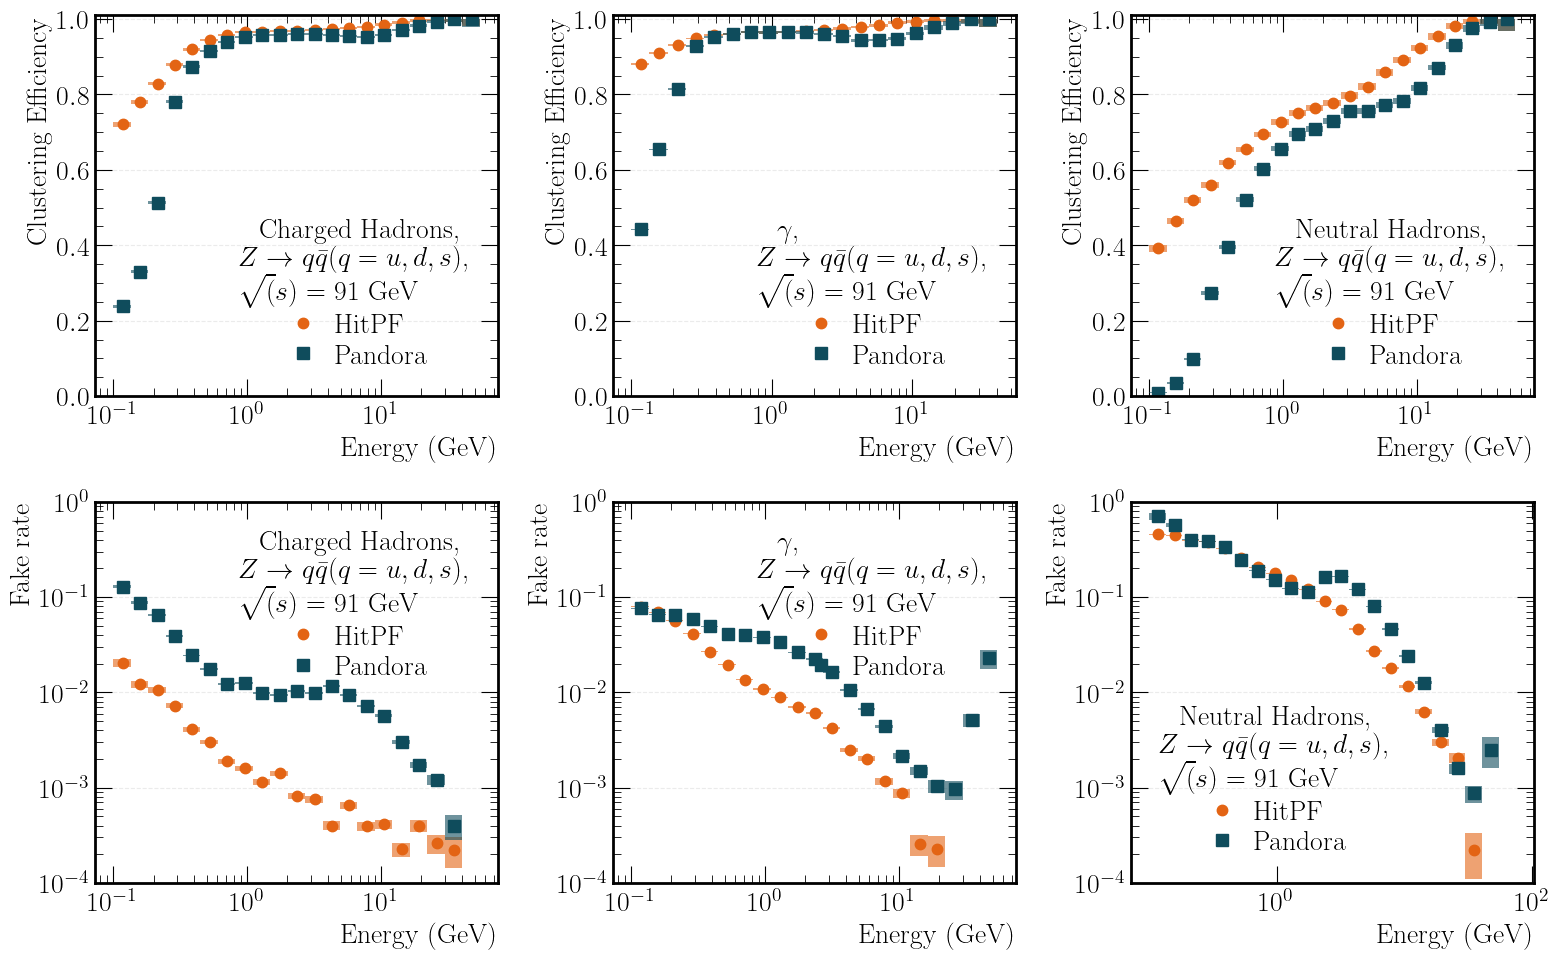

In [55]:
################################### Efficiency plot #####################################################################################################################################################################
######################################################################################################################################################################################################
fig_eff, ax_eff = plt.subplots(2, 3, figsize=(16, 10))
import matplotlib
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
size_font = 20
colors_list = ["#0F4C5C", "#E36414", "#E36414"]
STYLE_OURS = dict(color="#E36414",  marker='.', linestyle='None', markersize=15) #lw=2.5, 
STYLE_PANDORA = dict(color="#0F4C5C" ,  marker='s', linestyle='None', markersize=8)
ax_eff[0,1].plot(eff_dic["photons"]["energy_eff_" + str(0)][:-1],
            eff_dic["photons"]["eff" + "_" + str(0)][:-1], **STYLE_OURS, label="HitPF",)
ax_eff[0,1].plot(eff_dic["photons"]["energy_eff_p"][:-1],
            eff_dic["photons"]["eff_p"][:-1], **STYLE_PANDORA, label="Pandora",)
ax_eff[0,1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,1].set_ylabel("Clustering Efficiency",fontsize=size_font)
plot_error_bars(eff_dic["photons"],ax_eff[0,1], "")
plot_error_bars_pandora(eff_dic["photons"],ax_eff[0,1], "")
ax_eff[0,1].set_ylim([0,1.01])
ls =0.2
htp = 0.4
ax_eff[0,1].legend(fontsize = size_font, title_fontsize=size_font, title=r"$\gamma$,\\$Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)
y = eff_dic["photons"]["eff_0"]
#################################
ax_eff[0,0].plot(eff_dic["pions"]["energy_eff_" + str(0)][:-1],
            eff_dic["pions"]["eff" + "_" + str(0)][:-1],  label="HitPF", **STYLE_OURS)
ax_eff[0,0].plot(eff_dic["pions"]["energy_eff_p"][:-1],
            eff_dic["pions"]["eff_p"][:-1], label="Pandora", **STYLE_PANDORA)
plot_error_bars(eff_dic["pions"],ax_eff[0,0], "")
# ax_eff[0,0].set_title("Charged Hadrons",fontsize=size_font)
ax_eff[0,0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,0].set_ylabel("Clustering Efficiency",fontsize=size_font)
ax_eff[0,0].set_ylim([0,1.01])
ax_eff[0,0].legend(fontsize = size_font, title_fontsize=size_font, title=r"Charged Hadrons,\\$Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)
plot_error_bars_pandora(eff_dic["pions"],ax_eff[0,0], "")
#################################
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_" + str(0)][:-1],
            eff_dic["kaons"]["eff" + "_" + str(0)][:-1], label="HitPF", **STYLE_OURS)
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_p"][:-1],
            eff_dic["kaons"]["eff_p"][:-1], label="Pandora", **STYLE_PANDORA)
plot_error_bars(eff_dic["kaons"],ax_eff[0,2], "")
plot_error_bars_pandora(eff_dic["kaons"],ax_eff[0,2], "")
ax_eff[0,2].set_xlabel("Energy (GeV)",fontsize=size_font)
# ax_eff[0,2].set_title("Neutral Hadrons",fontsize=size_font)
ax_eff[0,2].set_ylabel("Clustering Efficiency",fontsize=size_font)
ax_eff[0,2].set_ylim([0,1.01])
ax_eff[0,2].legend(fontsize = size_font,  title_fontsize=size_font,title=r"Neutral Hadrons,\\$Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)
##Fake rate #################################
ax_eff[1,1].plot(eff_dic["photons"]["energy_fakes_" + str(0)],
            eff_dic["photons"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,1].plot(eff_dic["photons"]["energy_fakes_p"],
        eff_dic["photons"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,1].set_ylabel("Fake rate",fontsize=size_font)
# ax_eff[1,1].set_title(r"$\gamma$",fontsize=size_font)
ax_eff[1,1].set_ylim([1e-4,1])
ax_eff[1,1].legend(fontsize = size_font,  title_fontsize=size_font,title=r"$\gamma$,\\ $Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV", loc="upper right",labelspacing=ls,handletextpad=htp)
pot_error_bar_fakes(eff_dic["photons"], ax_eff[1,1], i=0)
pot_error_bar_fakes_pandora(eff_dic["photons"], ax_eff[1,1], i=0)
ax_eff[1,1].set_yscale("log")
#################################
ax_eff[1,0].plot(eff_dic["pions"]["energy_fakes_" + str(0)],
    eff_dic["pions"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,0].plot(eff_dic["pions"]["energy_fakes_p"],
        eff_dic["pions"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,0].set_ylabel("Fake rate",fontsize=size_font)
# ax_eff[1,0].set_title("Chardged Hadrons",fontsize=size_font)
ax_eff[1,0].legend(fontsize = size_font,  title_fontsize=size_font,title=r"Charged Hadrons,\\$Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV", loc="upper right",labelspacing=ls,handletextpad=htp)
pot_error_bar_fakes(eff_dic["pions"], ax_eff[1,0], i=0)
pot_error_bar_fakes_pandora(eff_dic["pions"], ax_eff[1,0], i=0)
ax_eff[1,0].set_ylim([1e-4,1])
ax_eff[1,0].set_yscale("log")
ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_" + str(0)],
    eff_dic["kaons"]["fakes_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_p"],
        eff_dic["kaons"]["fakes_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,2].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,2].set_ylabel("Fake rate",fontsize=size_font)
# ax_eff[1,2].set_title("Neutral Hadrons",fontsize=size_font)
ax_eff[1,2].legend(fontsize = size_font, title_fontsize=size_font, title=r"Neutral Hadrons,\\$Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV", loc="lower left",labelspacing=ls,handletextpad=htp)
pot_error_bar_fakes(eff_dic["kaons"], ax_eff[1,2], i=0)
pot_error_bar_fakes_pandora(eff_dic["kaons"], ax_eff[1,2], i=0)
ax_eff[1,2].set_ylim([1e-4,1])
ax_eff[1,2].set_yscale("log")
legend_elements = [
    Line2D([0], [0], **STYLE_OURS, label="HitPF"),
    Line2D([0], [0], **STYLE_PANDORA, label="PandoraPFA"),
]


for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)

plt.rcParams['font.size'] = size_font
plt.rcParams['font.family'] = "serif"
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
fig_eff.tight_layout()
fig_eff.savefig(os.path.join(PATH_store_summary_plots, "overview_Efficiency_FakeRate_v1_allEcor_v1.pdf"))

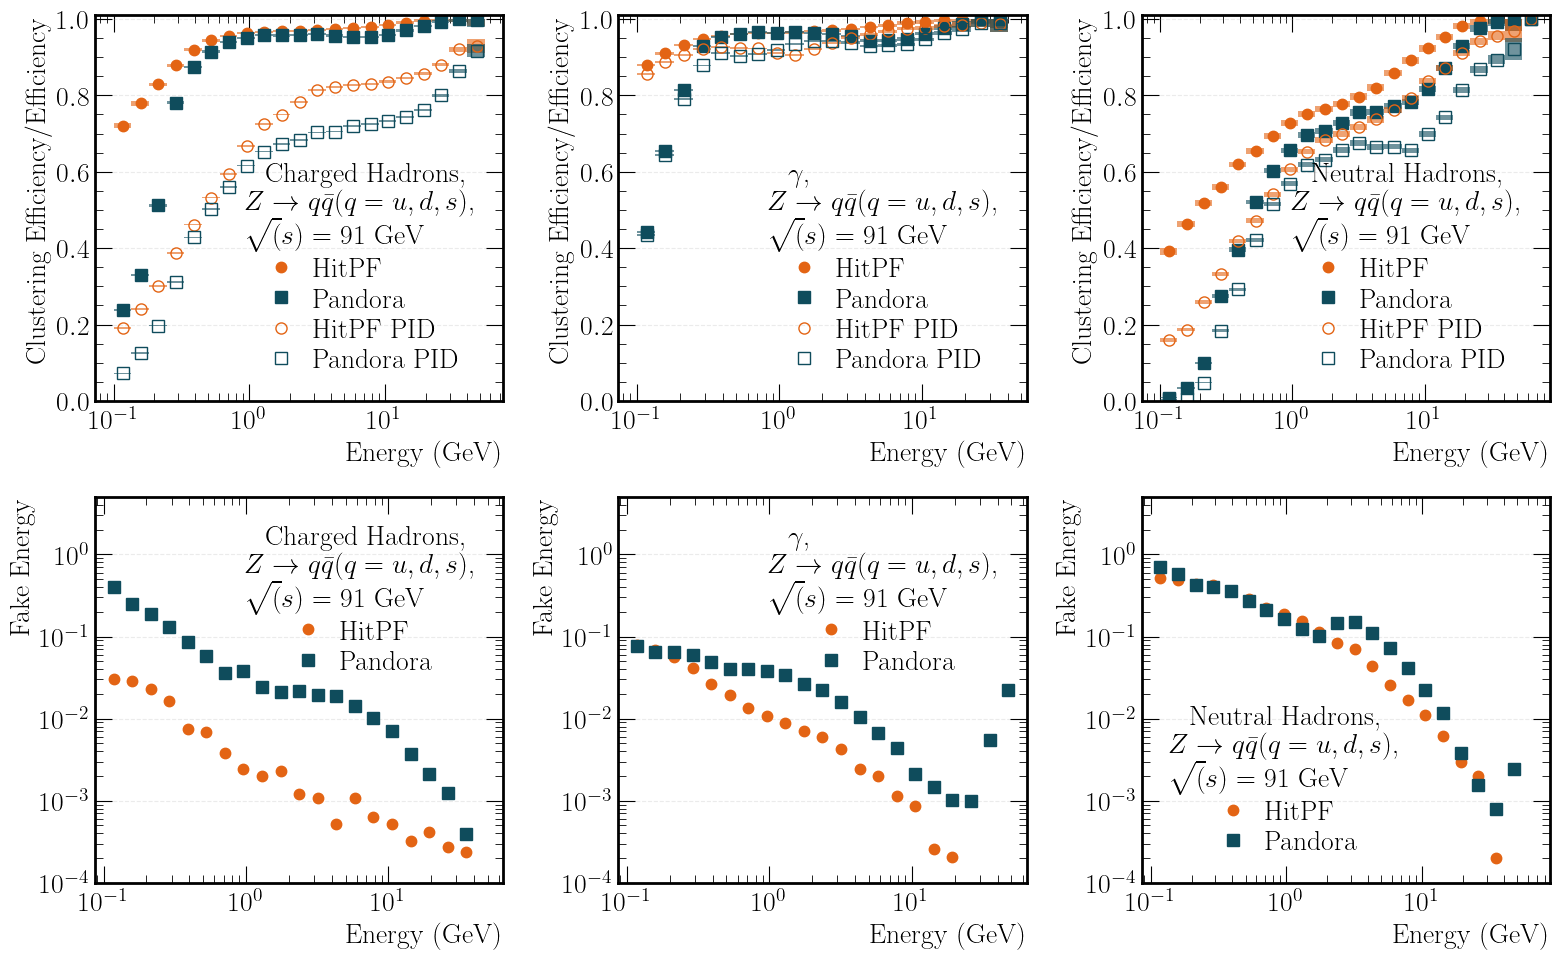

In [63]:
################################### Efficiency plot  FOR THE APPENDIX WITH PID AND FAKE ENERGY#####################################################################################################################################################################
######################################################################################################################################################################################################
fig_eff, ax_eff = plt.subplots(2, 3, figsize=(16, 10))
import matplotlib
plt.rc("text", usetex=True)
plt.rc("font", family="serif")

colors_list = ["#0F4C5C", "#E36414", "#E36414"]
# STYLE_OURS = dict(color="#0F4C5C",  marker='.', linestyle='None', markersize=10) #lw=2.5, 
# STYLE_PANDORA = dict(color="#E36414",  marker='x', linestyle='None', markersize=10)
STYLE_OURS_pid = dict(color="#E36414",  marker='o', linestyle='None', markersize=8,  markerfacecolor='none') #lw=2.5, 
STYLE_PANDORA_pid = dict(color="#0F4C5C",  marker='s', linestyle='None', markersize=8,  markerfacecolor='none')
ax_eff[0,1].plot(eff_dic["photons"]["energy_eff_" + str(0)][:-1],
            eff_dic["photons"]["eff" + "_" + str(0)][:-1], **STYLE_OURS,   label="HitPF")
ax_eff[0,1].plot(eff_dic["photons"]["energy_eff_p"][:-1],
            eff_dic["photons"]["eff_p"][:-1], **STYLE_PANDORA, label="Pandora")

ax_eff[0,1].plot(eff_dic["photons"]["energy_eff_" + str(0)][:-1],
            eff_dic["photons"]["eff_pid" + "_" + str(0)][:-1],label="HitPF PID", **STYLE_OURS_pid)
ax_eff[0,1].plot(eff_dic["photons"]["energy_eff_p"][:-1],
            eff_dic["photons"]["eff_p_pid"][:-1], label="Pandora PID", **STYLE_PANDORA_pid)
ax_eff[0,1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,1].set_ylabel("Clustering Efficiency/Efficiency",fontsize=size_font)
ax_eff[0,1].set_ylim([0,1.01])
ax_eff[0,1].legend(fontsize = size_font, title_fontsize=size_font, title=r"$\gamma$,\\$Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)
# ax_eff[0,1].set_title(r"$\gamma$",fontsize=size_font)
plot_error_bars(eff_dic["photons"],ax_eff[0,1], "")
plot_error_bars_pandora(eff_dic["photons"],ax_eff[0,1], "")
plot_error_bars(eff_dic["photons"],ax_eff[0,1], "_pid")
plot_error_bars_pandora(eff_dic["photons"],ax_eff[0,1], "_pid")


bins = np.exp(np.arange(np.log(0.1), np.log(80), 0.7))
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_widths = np.diff(bins)
y = eff_dic["photons"]["eff_0"]
#################################
ax_eff[0,0].plot(eff_dic["pions"]["energy_eff_" + str(0)][:-1],
            eff_dic["pions"]["eff" + "_" + str(0)][:-1],  label="HitPF", **STYLE_OURS)
ax_eff[0,0].plot(eff_dic["pions"]["energy_eff_p"][:-1],
            eff_dic["pions"]["eff_p"][:-1], label="Pandora", **STYLE_PANDORA)
ax_eff[0,0].plot(eff_dic["pions"]["energy_eff_" + str(0)][:-1],
            eff_dic["pions"]["eff_pid" + "_" + str(0)][:-1],label="HitPF PID", **STYLE_OURS_pid)
ax_eff[0,0].plot(eff_dic["pions"]["energy_eff_p"][:-1],
            eff_dic["pions"]["eff_p_pid"][:-1], label="Pandora PID", **STYLE_PANDORA_pid)
plot_error_bars(eff_dic["pions"],ax_eff[0,0], "")
plot_error_bars(eff_dic["pions"],ax_eff[0,0], "_pid")
plot_error_bars_pandora(eff_dic["pions"],ax_eff[0,0], "_pid")
# ax_eff[0,1].set_title("Charged Hadrons",fontsize=size_font)
ax_eff[0,0].legend(fontsize = size_font, title_fontsize=size_font, title=r"Charged Hadrons,\\$Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)
ax_eff[0,0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[0,0].set_ylabel("Clustering Efficiency",fontsize=size_font)
ax_eff[0,0].set_ylim([0,1.01])
# ax_eff[0,1].set_xlabel("Energy (GeV)",fontsize=size_font)
# ax_eff[0,1].set_ylabel("Clustering Efficiency/Efficiency",fontsize=size_font)
ax_eff[0,0].set_ylabel("Clustering Efficiency/Efficiency",fontsize=size_font)
plot_error_bars_pandora(eff_dic["pions"],ax_eff[0,0], "")
#################################
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_" + str(0)],
            eff_dic["kaons"]["eff" + "_" + str(0)], label="HitPF", **STYLE_OURS)
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_p"],
            eff_dic["kaons"]["eff_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_" + str(0)],
            eff_dic["kaons"]["eff_pid" + "_" + str(0)],label="HitPF PID", **STYLE_OURS_pid)
ax_eff[0,2].plot(eff_dic["kaons"]["energy_eff_p"],
            eff_dic["kaons"]["eff_p_pid"], label="Pandora PID", **STYLE_PANDORA_pid)
ax_eff[0,2].legend(fontsize = size_font,  title_fontsize=size_font,title=r"Neutral Hadrons,\\$Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV", loc="lower right",labelspacing=ls,handletextpad=htp)

plot_error_bars(eff_dic["kaons"],ax_eff[0,2], "")
plot_error_bars_pandora(eff_dic["kaons"],ax_eff[0,2], "")
plot_error_bars(eff_dic["kaons"],ax_eff[0,2], "_pid")
plot_error_bars_pandora(eff_dic["kaons"],ax_eff[0,2], "_pid")
ax_eff[0,2].set_xlabel("Energy (GeV)",fontsize=size_font)
# ax_eff[0,2].set_title("Neutral Hadrons",fontsize=size_font)
ax_eff[0,2].set_ylabel("Clustering Efficiency/Efficiency",fontsize=size_font)
ax_eff[0,2].set_ylim([0,1.01])
##Fake rate #################################
ax_eff[1,1].plot(eff_dic["photons"]["energy_fakes_" + str(0)],
            eff_dic["photons"]["fake_percent_energy_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,1].plot(eff_dic["photons"]["energy_fakes_p"],
        eff_dic["photons"]["fake_percent_energy_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,1].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,1].set_ylabel("Fake Energy %",fontsize=size_font)
# ax_eff[1,1].set_title(r"$\gamma$",fontsize=size_font)
ax_eff[1,1].legend(fontsize = size_font, title_fontsize=size_font,title=r"$\gamma$,\\$Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV", loc="upper right",labelspacing=ls,handletextpad=htp)
ax_eff[1,1].set_ylim([1e-4,5])
ax_eff[1,1].set_yscale("log")
#################################
ax_eff[1,0].plot(eff_dic["pions"]["energy_fakes_" + str(0)],
    eff_dic["pions"]["fake_percent_energy_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,0].plot(eff_dic["pions"]["energy_fakes_p"],
        eff_dic["pions"]["fake_percent_energy_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,0].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,0].set_ylabel("Fake Energy %",fontsize=size_font)
# ax_eff[1,0].set_title("Chardged Hadrons",fontsize=size_font)
ax_eff[1,0].legend(fontsize = size_font,  title_fontsize=size_font, title=r"Charged Hadrons,\\$Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV", loc="upper right",labelspacing=ls,handletextpad=htp)
ax_eff[1,0].set_ylim([1e-4,5])
ax_eff[1,0].set_yscale("log")
ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_" + str(0)],
    eff_dic["kaons"]["fake_percent_energy_" + str(0)],  label="HitPF", **STYLE_OURS)
ax_eff[1,2].plot(eff_dic["kaons"]["energy_fakes_p"],
        eff_dic["kaons"]["fake_percent_energy_p"], label="Pandora", **STYLE_PANDORA)
ax_eff[1,2].set_xlabel("Energy (GeV)",fontsize=size_font)
ax_eff[1,2].set_ylabel("Fake Energy %",fontsize=size_font)
# ax_eff[1,2].set_title("Neutral Hadrons",fontsize=size_font)
ax_eff[1,2].legend(fontsize = size_font,  title_fontsize=size_font,title=r"Neutral Hadrons,\\$Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV", loc="lower left",labelspacing=ls,handletextpad=htp)
ax_eff[1,2].set_ylim([1e-4,5])
ax_eff[1,2].set_yscale("log")

legend_elements = [
    Line2D([0], [0], **STYLE_OURS, label="HitPF"),
    Line2D([0], [0], **STYLE_PANDORA, label="PandoraPFA"),
]


for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)
plt.rcParams['font.size'] = size_font
plt.rcParams['font.family'] = "serif"
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
fig_eff.tight_layout()
fig_eff.savefig(os.path.join(PATH_store_summary_plots, "overview_Efficiency_FakeRate_PID_v2.pdf"))

In [71]:
# from src.utils.inference.event_metrics import get_response_for_event_energy
from src.utils.inference.event_metrics import calculate_event_energy_resolution, calculate_event_mass_resolution
from src.utils.inference.inference_metrics import get_sigma_gaussian
def get_response_for_event_energy(matched_pandora, matched_, perfect_pid=False, mass_zero=False, ML_pid=False, pandora=False):
    if pandora:
        (
            mean_p,
            variance_om_p,
            distr_p,
            x_p,
            _,
            _,
            _,
            mass_over_true_pandora,
        ) = calculate_event_energy_resolution(matched_pandora, True, False)
    (
        mean,
        variance_om,
        distr,
        x,
        mean_baseline,
        variance_om_baseline,
        _,
        mass_over_true_model,
    ) = calculate_event_energy_resolution(matched_, False, False)
    if pandora:
        dic_pandora = calculate_event_mass_resolution(matched_pandora, True, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid, fake=False)
    
    dic_model = calculate_event_mass_resolution(matched_, False, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid, fake=False)
    # mean_mass_perfect_PID, var_mass_perfect_PID, distr_mass_perfect_PID, mass_true_perfect_PID, _, _, E_over_true_perfect_PID, E_over_true_reco_perfect_PID = calculate_event_mass_resolution(matched_, False, perfect_pid=True, mass_zero=False, ML_pid=False,  fake=True)
    # matched_.calibrated_E = matched_.pred_showers_E
    df_copy = matched_.copy(deep=True)
    df_copy.true_showers_E = matched_.reco_showers_E
    # matched_pandora.pandora_calibrated_pfo = matched_pandora.pred_showers_E
    # matched_.pred_pos_matched = matched_.true_pos
    dic_perfect_E = calculate_event_mass_resolution(df_copy, False, perfect_pid=False, mass_zero=False, ML_pid=True, fake=False)
    if pandora:
        dic_perfect_E_pandora = calculate_event_mass_resolution(matched_pandora, True, perfect_pid=False, mass_zero=False, ML_pid=True, fake=False)
    (
        mean_energy_over_true,
        var_energy_over_true,
        _,
        _,
    ) = get_sigma_gaussian(dic_model["E_over_true"], np.linspace(0, 2, 400), epsilon=0.005)
    mean_predtotrue = np.median(dic_model["E_over_true"])
    p16 = np.percentile(dic_model["E_over_true"], 16)
    p84 = np.percentile(dic_model["E_over_true"], 84)
    var_predtotrue = p84 - p16

    mean_mass= np.median(dic_model["mass_over_true_p"] )
    p16 = np.percentile(dic_model["mass_over_true_p"] , 16)
    p84 = np.percentile(dic_model["mass_over_true_p"] , 84)
    var_mass= p84 - p16
    if pandora:
        (
            mean_energy_over_true_pandora,
            var_energy_over_true_pandora,
            _,
            _,
        ) = get_sigma_gaussian(dic_pandora["E_over_true"], np.linspace(0, 2, 400), epsilon=0.005)
        mean_predtotruep = np.median(dic_pandora["E_over_true"])
        p16 = np.percentile(dic_pandora["E_over_true"], 16)
        p84 = np.percentile(dic_pandora["E_over_true"], 84)
        var_predtotruep = p84 - p16
        mean_massp= np.median( dic_pandora["mass_over_true_p"]  )
        p16 = np.percentile( dic_pandora["mass_over_true_p"]  , 16)
        p84 = np.percentile( dic_pandora["mass_over_true_p"]  , 84)
        var_massp= p84 - p16
    dic = {}
    if pandora:
        dic["mean_p"] = mean_p
        dic["variance_om_p"] = variance_om_p
        dic["energy_resolutions_p"] = x_p
        dic["distributions_pandora"] = distr_p
        
        dic["mass_over_true_model_perfect_E_pandora"] = dic_perfect_E_pandora["mass_over_true_p"]
        dic["mass_pandora"] = dic_pandora["mass_pred_p"] 
        dic["mass_pandora_mean"] = dic_pandora["mass_pred_p_mean"]
        dic["mass_pandora_var"] = dic_pandora["mass_pred_p_var"]
        dic["mass_model_mean16p"] = mean_massp
        dic["mass_model_var16p"] = var_massp
        dic["mass_true"] =  dic_pandora["mass_true"]
        dic["mass_true_mean"] =  dic_pandora["mass_true_mean"]
        dic["mass_true_var"] =  dic_pandora["mass_true_var"]
        dic["mass_over_true_model_perfect_E"] = dic_perfect_E["mass_over_true_p"]
        dic["mass_over_true_pandora"] = dic_pandora["mass_over_true_p"]
        dic["var_mass_pandora"] = dic_pandora["var_mass"]
        dic["mean_mass_pandora"] = dic_pandora["mean_mass"]
        dic["energy_over_true_pandora"] = dic_pandora["E_over_true"]
        dic["energy_over_true_reco_pandora"] = dic_pandora["E_over_true_reco"]
        dic["var_energy_over_true_pandora"] = var_energy_over_true_pandora
        dic["mean_energy_over_true_pandora"] = mean_energy_over_true_pandora
        dic["var_energy_over_true_pandora16"] = var_predtotruep
        dic["mean_energy_over_true_pandora16"] = mean_predtotruep

    dic["mass_over_true_model"] = dic_model["mass_over_true_p"]
    dic["variance_om"] = variance_om
    dic["mean"] = mean
    dic["energy_resolutions"] = x
    dic["mean_baseline"] = mean_baseline
    dic["variance_om_baseline"] = variance_om_baseline
    dic["distributions_model"] = distr
    dic["mass_model"] = dic_model["mass_pred_p"] 
    dic["mass_model_mean"] = dic_model["mass_pred_p_mean"]
    dic["mass_model_var"] = dic_model["mass_pred_p_var"]
    dic["mass_model_mean16"] = mean_mass
    dic["mass_model_var16"] = var_mass
    dic["mean_mass_model"] = dic_model["mean_mass"]
    dic["var_mass_model"] =  dic_model["var_mass"]
    dic["energy_over_true"] = dic_model["E_over_true"]
    dic["mean_energy_over_true"] = mean_energy_over_true
    dic["var_energy_over_true"] = var_energy_over_true
    dic["mean_energy_over_true16"] = mean_predtotrue
    dic["var_energy_over_true16"] = var_predtotrue
    dic["energy_over_true_reco"] = dic_model["E_over_true_reco"]
    
    return dic

colors = {"ML": "red", "ML GTC": "green"}



PATH_store = PATH_store_summary_plots
label_ML="HitPF"
label_ML_GTC="ML GTC",
color_ML_GTC="green"
filename="mass_resolution_comp_corrected_E_mass.pdf"
perfect_pid = False
mass_zero = False
ML_pid = True
matched_all = {label_ML: sd_hgb, label_ML_GTC: sd_hgb}
matched_pandora = sd_pandora
event_res_dic = {} 
for key in matched_all:
        matched_ = matched_all[key]
        event_res_dic[key] = get_response_for_event_energy(
                matched_pandora, matched_, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid, pandora=True
            )




In [72]:
dic=  event_res_dic[label_ML]
print(dic["mass_model_mean"])
print(dic["mass_model_var"])
print(dic["mass_model_mean16"]/2   )
print(dic["mass_model_var16"])
print(dic["mean_mass_model"] )
print(dic["var_mass_model"] )
print("pandora", dic["mass_model_mean16p"] )
print("pandora",dic["mass_model_var16p"])

90.34667619728377
0.03904426599153444
0.9959494484378264
0.08384478613953794
1.0050125313283207
0.0399002493765585
pandora 1.0075935216582814
pandora 0.09284250595488874


In [82]:
dic["mass_model_var16"]/(2*dic["mass_model_mean16"]), dic["mass_model_var16p"]/(2*dic["mass_model_mean16p"])

(0.0420928925012463, 0.04607140873736962)

In [73]:
print(dic["var_mass_pandora"])
print(dic["mean_mass_pandora"])


0.04738154613466329
1.0050125313283207


In [83]:
mean_m_model = round((event_res_dic[label_ML]["mean_mass_model"]), 4)
var_m_model = round((event_res_dic[label_ML]["var_mass_model"]), 4)
mean_m_pandora = round((event_res_dic[label_ML]["mean_mass_pandora"]), 3)
var_m_pandora = round((event_res_dic[label_ML_GTC]["var_mass_pandora"]), 3)
var_m_model, mean_m_model, var_m_model/mean_m_model, var_m_pandora, mean_m_pandora,  var_m_pandora/mean_m_pandora

(0.0399, 1.005, 0.039701492537313435, 0.047, 1.005, 0.04676616915422886)

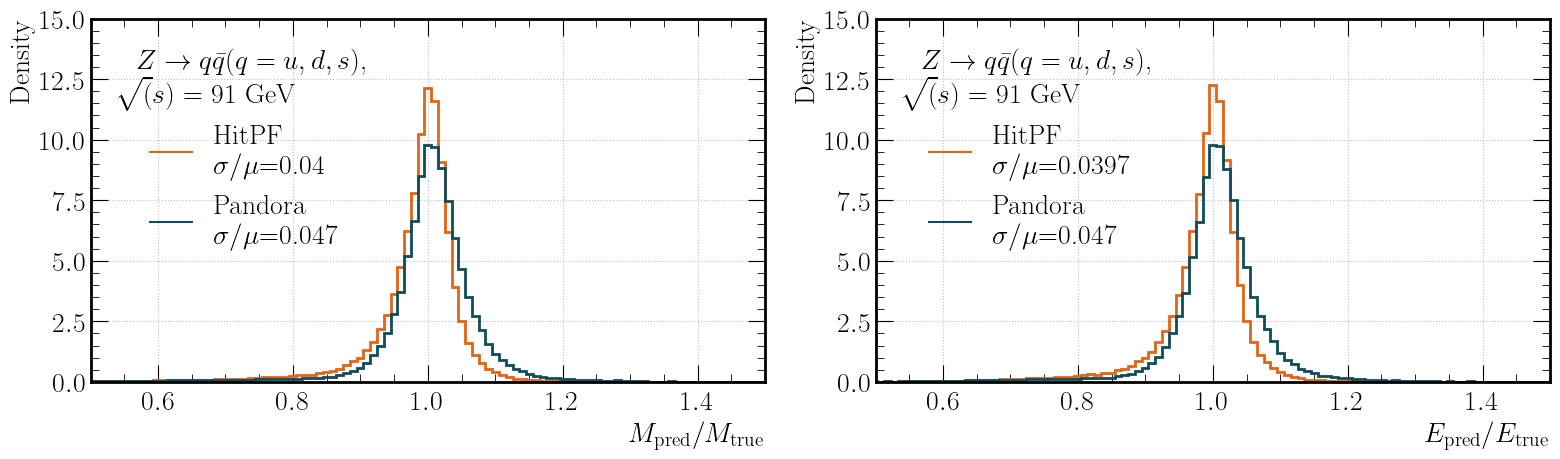

In [88]:
old_font_size = matplotlib.rcParams['font.size']
matplotlib.rcParams.update({'font.size': size_font})
fig, ax = plt.subplots(1, 2,figsize=(16, 5))
ax[0].set_xlabel(r"$M_{\mathrm{pred}}/M_{\mathrm{true}}$")
bins = np.linspace(0, 2, 200)
ax[0].hist(
    event_res_dic[label_ML]["mass_over_true_model"],
    bins=bins,
    histtype="step",
    color= "#E36414", 
    density=True, linewidth=2)
p16p = np.percentile(event_res_dic[label_ML]["mass_over_true_pandora"], 16)
p84p = np.percentile(event_res_dic[label_ML]["mass_over_true_pandora"], 84)
p16 = np.percentile(event_res_dic[label_ML]["mass_over_true_model"], 16)
p84 = np.percentile(event_res_dic[label_ML]["mass_over_true_model"], 84)
# ax[0].axvline(x=p16p, color='b', linestyle='-',)
# ax[0].axvline(x=p84p, color='b', linestyle='-',)
# ax[0].axvline(x=p16, color='orange', linestyle='-',)
# ax[0].axvline(x=p84, color='orange', linestyle='-',)
ax[0].hist(
    event_res_dic[label_ML]["mass_over_true_pandora"],
    bins=bins,
    histtype="step",
    color="#0F4C5C",
    density=True,
    linewidth=2)

ax[0].grid()


var_m_model = round((event_res_dic[label_ML]["var_mass_model"]/event_res_dic[label_ML]["mean_mass_model"]), 4)
var_m_pandora = round((event_res_dic[label_ML_GTC]["var_mass_pandora"]/event_res_dic[label_ML]["mean_mass_pandora"]), 3)
sigma_e_over_true_pandora = round(event_res_dic[label_ML]["var_energy_over_true_pandora"]/event_res_dic[label_ML]["mean_energy_over_true_pandora"], 3)
sigma_e_over_true = round(event_res_dic[label_ML]["var_energy_over_true"]/event_res_dic[label_ML]["mean_energy_over_true"], 3)
# mean_e_over_true_gtc, sigma_e_over_true_gtc = round(event_res_dic[label_ML_GTC]["mean_energy_over_true"], 3), round(
#     event_res_dic[label_ML_GTC]["var_energy_over_true"], 3)
ax[1].hist(event_res_dic[label_ML]["energy_over_true"], bins=bins, histtype="step",
            # label=r"ML $\mu$={} $\sigma / \mu$={}".format(mean_e_over_true, sigma_e_over_true),
            color="#E36414",
            density=True, linewidth=2)
   
ax[1].hist(event_res_dic[label_ML]["energy_over_true_pandora"], bins=bins, histtype="step",
                    # label=r"Pandora $\mu$={} $\sigma / \mu$={}".format(mean_e_over_true_pandora,
                    #                                                     sigma_e_over_true_pandora),
                    
                    color="#0F4C5C",
                    density=True, linewidth=2)

ax[1].grid(1)
ax[1].set_xlabel(r"$E_{\mathrm{pred}} / E_{\mathrm{true}}$")
# ax[1].legend(loc='upper left')

from matplotlib.lines import Line2D
custom_line1 = Line2D([0], [0], color="#E36414",label="HitPF "+"\n"+"$\sigma/\mu$={}".format(var_m_model))
# custom_line_gt = Line2D([0], [0], color="green",label="ML GT "+"\n"+"$\sigma/\mu$={}".format(round((event_res_dic["ML GTC"]["var_mass_model"]), 2),
#     ))
custom_line_pandora = Line2D([0], [0], color="#0F4C5C",label="Pandora "+"\n"+"$\sigma/\mu$={}".format(var_m_pandora))

custom_line2 = Line2D([0], [0], color="#E36414",label="HitPF "+"\n"+"$\sigma/\mu$={}".format(sigma_e_over_true))

custom_line_pandora2 = Line2D([0], [0], color="#0F4C5C",label="Pandora "+"\n"+"$\sigma/\mu$={}".format(sigma_e_over_true_pandora))
ax[1].legend(handles=[custom_line1, custom_line_pandora],loc='upper left',title_fontsize=size_font,title=r"$Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV")
ax[0].legend(handles=[custom_line2, custom_line_pandora2],loc='upper left',title_fontsize=size_font,title=r"$Z\rightarrow q \bar q (q=u,d,s)$,\\ $\sqrt(s)=$ 91 GeV")

# ax.legend(loc='upper left')
ax[0].set_xlim([0.5, 1.5])
ax[1].set_xlim([0.5, 1.5])
ax[0].set_ylim([0, 15])
ax[1].set_ylim([0, 15])
ax[0].set_ylabel("Density")
ax[1].set_ylabel("Density")
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font
fig.tight_layout()
fig.savefig(os.path.join(PATH_store, "mass_plot_v1.pdf"), bbox_inches="tight")



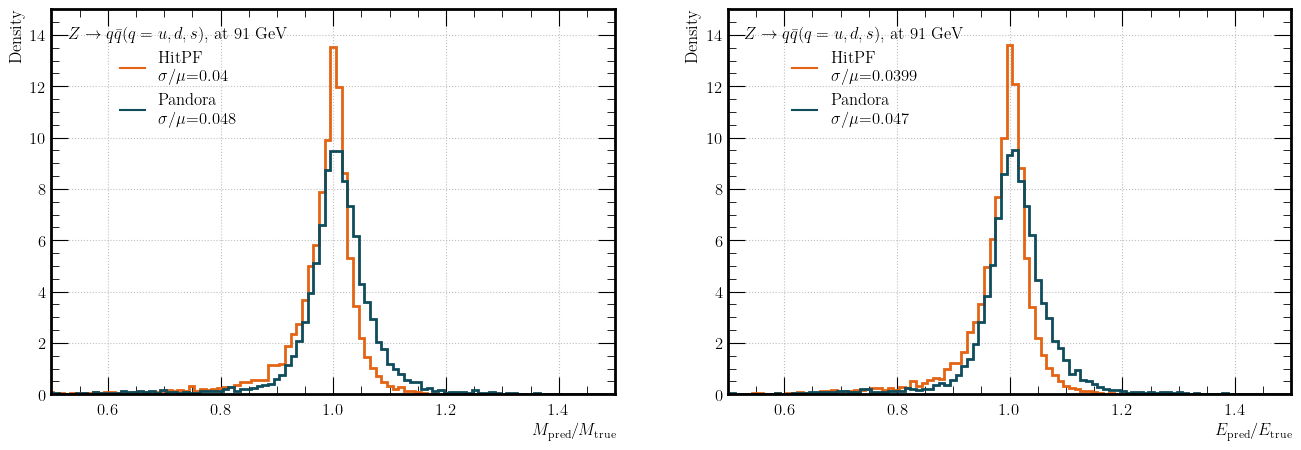

In [158]:
old_font_size = matplotlib.rcParams['font.size']
matplotlib.rcParams.update({'font.size': size_font})
fig, ax = plt.subplots(1, 2,figsize=(16, 5))
ax[0].set_xlabel(r"$M_{\mathrm{pred}}/M_{\mathrm{true}}$")
bins = np.linspace(0, 2, 200)
ax[0].hist(
    event_res_dic[label_ML]["mass_over_true_model"],
    bins=bins,
    histtype="step",
    color= "#E36414", 
    density=True, linewidth=2)

ax[0].hist(
    event_res_dic[label_ML]["mass_over_true_pandora"],
    bins=bins,
    histtype="step",
    color="#0F4C5C",
    density=True,
    linewidth=2)

ax[0].grid()


mean_m_model = round((event_res_dic[label_ML]["mean_mass_model"]), 4)
var_m_model = round((event_res_dic[label_ML]["var_mass_model"]), 4)
mean_m_pandora = round((event_res_dic[label_ML]["mean_mass_pandora"]), 3)
var_m_pandora = round((event_res_dic[label_ML_GTC]["var_mass_pandora"]), 3)
mean_e_over_true_pandora, sigma_e_over_true_pandora = round(event_res_dic[label_ML]["mean_energy_over_true_pandora"], 3), round(
    event_res_dic[label_ML]["var_energy_over_true_pandora"], 3)
mean_e_over_true, sigma_e_over_true = round(event_res_dic[label_ML]["mean_energy_over_true"], 3), round(
    event_res_dic[label_ML]["var_energy_over_true"], 3)
mean_e_over_true_gtc, sigma_e_over_true_gtc = round(event_res_dic[label_ML_GTC]["mean_energy_over_true"], 3), round(
    event_res_dic[label_ML_GTC]["var_energy_over_true"], 3)
ax[1].hist(event_res_dic[label_ML]["energy_over_true"], bins=bins, histtype="step",
            # label=r"ML $\mu$={} $\sigma / \mu$={}".format(mean_e_over_true, sigma_e_over_true),
            color="#E36414",
            density=True, linewidth=2)
   
ax[1].hist(event_res_dic[label_ML]["energy_over_true_pandora"], bins=bins, histtype="step",
                    # label=r"Pandora $\mu$={} $\sigma / \mu$={}".format(mean_e_over_true_pandora,
                    #                                                     sigma_e_over_true_pandora),
                    
                    color="#0F4C5C",
                    density=True, linewidth=2)

ax[1].grid(1)
ax[1].set_xlabel(r"$E_{\mathrm{pred}} / E_{\mathrm{true}}$")
# ax[1].legend(loc='upper left')

from matplotlib.lines import Line2D
custom_line1 = Line2D([0], [0], color="#E36414",label="HitPF "+"\n"+"$\sigma/\mu$={}".format(var_m_model))
# custom_line_gt = Line2D([0], [0], color="green",label="ML GT "+"\n"+"$\sigma/\mu$={}".format(round((event_res_dic["ML GTC"]["var_mass_model"]), 2),
#     ))
custom_line_pandora = Line2D([0], [0], color="#0F4C5C",label="Pandora "+"\n"+"$\sigma/\mu$={}".format(var_m_pandora))

custom_line2 = Line2D([0], [0], color="#E36414",label="HitPF "+"\n"+"$\sigma/\mu$={}".format(sigma_e_over_true))

custom_line_pandora2 = Line2D([0], [0], color="#0F4C5C",label="Pandora "+"\n"+"$\sigma/\mu$={}".format(sigma_e_over_true_pandora))
ax[1].legend(handles=[custom_line1, custom_line_pandora],loc='upper left',title_fontsize=size_font,title=r"$Z\rightarrow q \bar q (q=u,d,s)$, at 91 GeV")
ax[0].legend(handles=[custom_line2, custom_line_pandora2],loc='upper left',title_fontsize=size_font,title=r"$Z\rightarrow q \bar q (q=u,d,s)$, at 91 GeV")

# ax.legend(loc='upper left')
ax[0].set_xlim([0.5, 1.5])
ax[1].set_xlim([0.5, 1.5])
ax[0].set_ylim([0, 15])
ax[1].set_ylim([0, 15])
ax[0].set_ylabel("Density")
ax[1].set_ylabel("Density")
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font
# fig.tight_layout()
# fig.savefig(os.path.join(PATH_store, "new_ecor.pdf"), bbox_inches="tight")



In [94]:
sd_hgb1.keys()

Index(['true_showers_E', 'reco_showers_E', 'pred_showers_E',
       'e_pred_and_truth', 'pid', 'calibration_factor', 'calibrated_E', 'step',
       'number_batch', 'is_track_in_cluster', 'is_track_correct',
       'is_track_in_MC', 'distance_to_cluster_MC', 'vertex', 'ECAL_hits',
       'HCAL_hits', 'gen_status', 'labels', 'pred_pos_matched',
       'pred_pid_matched', 'pred_ref_pt_matched', 'matched_extra_features',
       'true_pos', 'pid_4_class_true'],
      dtype='object')

In [89]:
from src.utils.inference.per_particle_metrics import get_mask_id, particle_masses, particle_masses_4_class, safeint
from src.utils.inference.inference_metrics import get_sigma_gaussian
from src.utils.inference.per_particle_metrics import (
    plot_per_energy_resolution2_multiple, plot_confusion_matrix, plot_confusion_matrix_pandora
    , calc_unit_circle_dist, plot_per_energy_resolution2, analyze_fakes, analyze_fakes_PID,
    plot_cm_per_energy, plot_fake_and_missed_energy_regions, quick_plot_mass,
    plot_cm_per_energy_on_overview
)
def calculate_response(matched, pandora, log_scale=False, tracks=False, perfect_pid=False, mass_zero=False, ML_pid=False, pid=None, ch=False):
    if log_scale:
        bins = np.exp(np.arange(np.log(0.5), np.log(60), 1))
    else:
        #bins = np.linspace(0, 51, 5)
        bins = [0.1,0.5,1,2,5,10,15,20,70]
    mean = []
    variance_om = []
    mean_baseline = []
    variance_om_baseline = []
    mean_true_rec = []
    variance_om_true_rec = []
    mean_errors = []
    variance_om_errors = []
    energy_resolutions = []
    energy_resolutions_reco = []
    distributions = []  # Distributions of E/E_{true} for plotting later
    distributions_reco = []
    mean_pxyz = []
    variance_pxyz = []
    masses = []
    is_track_in_cluster = []
    pxyz_true, pxyz_pred = [], []
    sigma_phi, sigma_theta = [], [] # for the angular resolution vs. energy
    distr_phi, distr_theta = [], []
    mean_cld = []
    variance_om_cld = []
    #binning = 1e-2 * 0.2
    if ch:
        print("using 1000 bins")
        number_bins = 3000 
    else:
        number_bins = 500
    bins_per_binned_E = np.linspace(0, 2, number_bins)

    for i in range(len(bins) - 1):
        bin_i = bins[i]
        bin_i1 = bins[i + 1]
        mask_above = matched["true_showers_E"] <= bin_i1
        mask_below = matched["true_showers_E"] > bin_i
        mask_check = ~pd.isna(matched["pred_showers_E"])
        mask = mask_below * mask_above * mask_check
        true_e = matched.true_showers_E[mask]
        true_rec = matched.reco_showers_E[mask]
        if pandora:
            pred_e = matched.pandora_calibrated_pfo[mask]
            pred_pxyz = np.array(matched.pandora_calibrated_pos[mask].tolist())
        else:
            pred_e = matched.calibrated_E[mask]
            pred_pxyz = np.array(matched.pred_pos_matched[mask].tolist())
        pred_e_nocor = matched.pred_showers_E[mask]
        trk_in_clust = matched.is_track_in_cluster[mask]
        if perfect_pid or mass_zero or ML_pid:
            if len(pred_pxyz):
                pred_pxyz /= np.linalg.norm(pred_pxyz, axis=1).reshape(-1, 1)
            if perfect_pid:
                m = np.array([particle_masses[abs(int(i))] for i in matched.pid[mask]])
            elif ML_pid:
                if pandora:
                    m = np.array([particle_masses[abs(int(i))] for i in matched.pandora_pid[mask]])
                else:
                    m = np.array([particle_masses_4_class.get(safeint(i), 0.0) for i in matched.pred_pid_matched[mask]])
            if mass_zero:
                m = np.array([0 for _ in range(len(matched.pid[mask]))])
            p_squared = (pred_e**2 - m**2).values
            pred_pxyz = np.sqrt(p_squared).reshape(-1, 1) * pred_pxyz
        true_pxyz = np.array(matched.true_pos[mask].tolist())

        if np.sum(mask) > 0:  # if the bin is not empty
            e_over_true = pred_e / true_e
            e_over_reco = pred_e_nocor / true_rec
            e_cld_plot = (pred_e-true_e) / true_e**2
            distributions.append(e_over_true)
  
            bins_per_binned_E = np.linspace(0, 2, number_bins)
            bins_per_binned_E_1 = np.linspace(0, 2, 2000)
            # (
            #     mean_predtotrue,
            #     var_predtotrue,
            #     err_mean_predtotrue,
            #     err_var_predtotrue,
            # ) = get_sigma_gaussian(e_over_true, bins_per_binned_E)
            print("number_bins", number_bins)
            distributions_reco.append(e_cld_plot)
            use_percentile = True
            if use_percentile==True:
                mean_predtotrue = np.median(e_over_true)
                p16 = np.percentile(e_over_true, 16)
                p84 = np.percentile(e_over_true, 84)
                var_predtotrue = p84 - p16
            else:

                mean_predtotrue, var_predtotrue = obtain_MPV_and_68(e_over_true,bins_per_binned_E, no_divide=True, epsilon=0.005)
                mean_predtotrue_cld, var_predtotrue_cld = obtain_MPV_and_68(e_over_reco,bins_per_binned_E_1, no_divide=True, epsilon=0.1)
 
            mean.append(mean_predtotrue)
            variance_om.append(np.abs(var_predtotrue))
            energy_resolutions.append((bin_i1 + bin_i) / 2)
            mean_cld.append(0)
            variance_om_cld.append(np.abs(0))

    return (
        mean,
        variance_om,
        mean_true_rec,
        variance_om_true_rec,
        energy_resolutions,
        energy_resolutions_reco,
        mean_baseline,
        variance_om_baseline,
        distributions,
        0,
        0,
        0,
        0,
        [0, 0],
        0,
        0,
        0,
        0,
        0,
        0,
        distributions_reco, 
        mean_cld, 
        variance_om_cld
    )
def get_response_for_id_i(id, matched_pandora, matched_, tracks=False, perfect_pid=False, mass_zero=False, ML_pid=False, pandora=False):
    if id ==[211]:
        ch=True
    else:
        ch = False
    if pandora:
        pids_pandora = np.abs(matched_pandora["pid"].values)
        mask_id = get_mask_id(id, pids_pandora)
        df_id_pandora = matched_pandora[mask_id]
    pids = np.abs(matched_["pid"].values)
    mask_id = get_mask_id(id, pids)
    df_id = matched_[mask_id]
    if pandora:
        (
            mean_p,
            variance_om_p,
            mean_true_rec_p,
            variance_om_true_rec_p,
            energy_resolutions_p,
            energy_resolutions_reco_p,
            mean_baseline,
            variance_om_baseline,
            e_over_e_distr_pandora,
            mean_errors_p,
            variance_errors_p,
            mean_pxyz_pandora, variance_om_pxyz_pandora, masses_pandora, pxyz_true_p, pxyz_pred_p, sigma_phi_pandora, sigma_theta_pandora, distr_phi_pandora, distr_theta_pandora, distr_E_reco_pandora, mp_cld, varp_cld
        ) = calculate_response(df_id_pandora, True, False, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid, pid=id[0], ch=ch)
        # Pandora: TODO: do some sort of PID for Pandora
    (
        mean,
        variance_om,
        mean_true_rec,
        variance_om_true_rec,
        energy_resolutions,
        energy_resolutions_reco,
        mean_baseline,
        variance_om_baseline,
        e_over_e_distr_model,
        mean_errors,
        variance_errors,
        mean_pxyz, variance_om_pxyz, masses, pxyz_true, pxyz_pred, sigma_phi, sigma_theta, distr_phi, distr_theta, distr_E_reco, m_cld, var_cld
    ) = calculate_response(df_id, False, False, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid, pid=id[0], ch=ch)
    # print("COR:__________________________________")
    # print(variance_om_p)
    # print(variance_om)
    # print("RECO:__________________________________")
    # print(variance_om_true_rec_p)
    # print(variance_om_true_rec)
    dic = {}
    if pandora:
        dic["mean_p"] = mean_p
        dic["variance_om_p"] = variance_om_p
        dic["variance_errors_p"] = np.array(variance_errors_p)
        dic["mean_errors_p"] = np.array(mean_errors_p)
        dic["energy_resolutions_p"] = np.array(energy_resolutions_p)
        dic["mean_p_reco"] = np.array(mean_true_rec_p)
        dic["variance_om_p_reco"] = np.array(variance_om_true_rec_p)
        dic["energy_resolutions_p_reco"] = np.array(energy_resolutions_reco_p)
        dic["distributions_pandora"] = e_over_e_distr_pandora
        dic["distributions_pandora_reco"] = distr_E_reco_pandora
        dic["mp_cld"] = mp_cld
        dic["varp_cld"] = varp_cld


    dic["variance_om"] = variance_om
    dic["mean"] = mean
    dic["mean_errors"] = np.array(mean_errors)
    dic["variance_errors"] = np.array(variance_errors)
    dic["energy_resolutions"] = np.array(energy_resolutions)
    dic["mean_reco"] = mean_true_rec
    dic["variance_om_reco"] = np.array(variance_om_true_rec)
    dic["energy_resolutions_reco"] = np.array(energy_resolutions_reco)
    dic["mean_baseline"] = mean_baseline
    dic["variance_om_baseline"] = np.array(variance_om_baseline)
    dic["distributions_model"] = e_over_e_distr_model
    dic["distributions_model_reco"] = distr_E_reco
    dic["m_cld"] = m_cld
    dic["var_cld"] = var_cld
    
    return dic

In [90]:
tracks = True
# from src.utils.inference.per_particle_metrics import get_response_for_id_i
perfect_pid = False
mass_zero = False
pandora = True
ML_pid = True
matched_pandora = sd_pandora1
matched_ = sd_hgb1
print("PID:22___________________________________________")
photons_dic = get_response_for_id_i(
    [22], matched_pandora[matched_pandora.pandora_pid==22], matched_[matched_.pred_pid_matched==3], tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero,pandora=pandora, 
    ML_pid=ML_pid
)


PID:22___________________________________________
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500


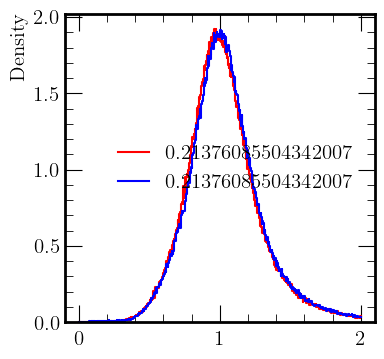

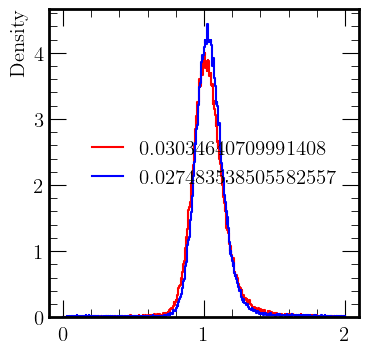

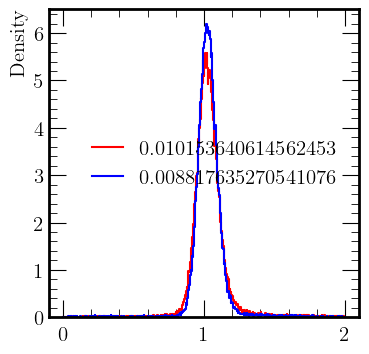

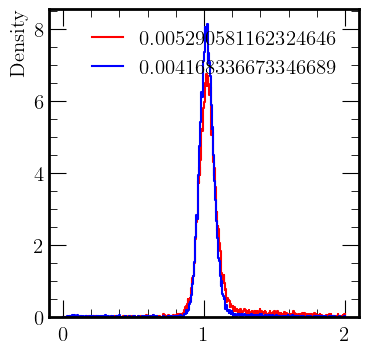

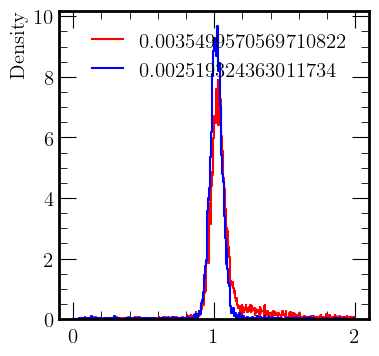

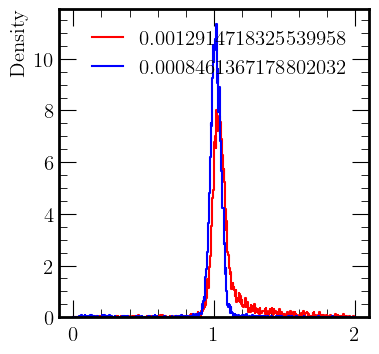

In [128]:
# number_binslen(np.exp(np.arange(np.log(0.5), np.log(60), 1)))
number_dist = len(photons_dic["distributions_pandora"])
import seaborn as sns
for i in range(number_dist):
    vars_p = photons_dic["variance_om_p"] / photons_dic["energy_resolutions_p"]
    vars = photons_dic["variance_om"] / photons_dic["energy_resolutions"]
    fig = plt.figure(figsize=(4,4))
    sns.histplot(photons_dic["distributions_pandora"][i], stat="density", bins= np.linspace(0, 2, 500), element="step", fill=False, color="red", label=str(vars_p[i]))
    sns.histplot(photons_dic["distributions_model"][i], stat="density", bins= np.linspace(0, 2, 500), element="step", fill=False, color="blue", label=str(vars[i]))
    # photons_dic2["distributions_model"]
    plt.legend()
    PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
    PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")

    fig.savefig(os.path.join(PATH_store, "photons1_"+str(i)+".png"), bbox_inches="tight")


In [91]:
print("PID:211___________________________________________")
matched_pandora_h = sd_pandora1[(np.abs(sd_pandora1.pid)==211)+(np.abs(sd_pandora1.pid)==2212)]
matched_h = sd_hgb1[(np.abs(sd_hgb1.pid)==211)+(np.abs(sd_hgb1.pid)==2212)]
matched_pandora_hadron= matched_pandora_h[(matched_pandora_h.pandora_pid==211)*(matched_h.pred_pid_matched==1)]
matched_hadron = matched_h[(matched_h.pred_pid_matched==1)*(matched_pandora_h.pandora_pid==211)]
# matched_hadron["calibrated_E"]= np.sqrt((matched_hadron["calibrated_E"])**2+(1.3957018E-01**2))
hadrons_dic2 = get_response_for_id_i(
    [211], matched_pandora_hadron, matched_hadron, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid,pandora=pandora
)



PID:211___________________________________________


/tmp/mgarciam/ipykernel_2328056/2546886231.py:2: UserWarning: evaluating in Python space because the '+' operator is not supported by numexpr for the bool dtype, use '|' instead.
  matched_pandora_h = sd_pandora1[(np.abs(sd_pandora1.pid)==211)+(np.abs(sd_pandora1.pid)==2212)]
/tmp/mgarciam/ipykernel_2328056/2546886231.py:3: UserWarning: evaluating in Python space because the '+' operator is not supported by numexpr for the bool dtype, use '|' instead.
  matched_h = sd_hgb1[(np.abs(sd_hgb1.pid)==211)+(np.abs(sd_hgb1.pid)==2212)]


using 1000 bins
number_bins 3000
number_bins 3000
number_bins 3000
number_bins 3000
number_bins 3000
number_bins 3000
number_bins 3000
number_bins 3000
using 1000 bins
number_bins 3000
number_bins 3000
number_bins 3000
number_bins 3000
number_bins 3000
number_bins 3000
number_bins 3000
number_bins 3000


In [199]:
# import awkward as ak
# outputs = ak.from_parquet("/eos/experiment/fcc/users/m/mgarciam/mlpf/CLD/train/Z_uds_CLD_o2_v05_eval_v1/05/pf_tree_10100.parquet")
# outputs["ygen_track"][0]
# outputs["pfo_track"][0]
# outputs["X_pandora"][0][5][-2]
# outputs["X_gen"][0][3][8], outputs["X_gen"][0][3][11]
# x = torch.sqrt(torch.norm(torch.tensor(outputs["X_track"][0][7][6:9]))**2+(1.3957018E-01**2))
# print("model E", f"{x:.17f}")

# y = outputs["X_pandora"][0][5][-2]
# print("pandora E", f"{y:.17f}")

# x = torch.norm(torch.tensor(outputs["X_track"][0][7][6:9]))
# print("model p", f"{x:.17f}")

# x = torch.norm(torch.tensor(outputs["X_track"][0][7][23:]))
# print("model p calo", f"{x:.17f}")

# y = outputs["X_pandora"][0][5][-1]
# print("pandora p",f"{y:.17f}")


In [73]:
# print(hadrons_dic2["mp_cld"])
# print(hadrons_dic2["m_cld"])
# print(hadrons_dic2["varp_cld"])
# print(hadrons_dic2["var_cld"])

/tmp/mgarciam/ipykernel_19041/2639138068.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0,20])


(0.0001, 1)

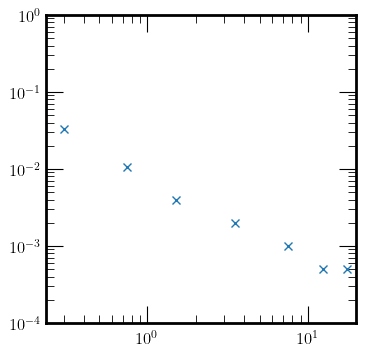

In [70]:
plt.figure(figsize=(4,4))
plt.plot(hadrons_dic2["energy_resolutions"], hadrons_dic2["var_cld"], 'x')
plt.yscale("log")
plt.xscale("log")
plt.xlim([0,20])
plt.ylim([1e-4,1])

In [89]:
print(hadrons_dic2["variance_om_p"])
print(hadrons_dic2["variance_om"])
print(hadrons_dic2["mean_p"])
print(hadrons_dic2["mean"])

[0.020340113371123625, 0.010670223407802548, 0.007335778592864273, 0.007002334111370356, 0.007002334111370412, 0.007002334111370412, 0.006668889629876551, 0.00633544514838269]
[0.02034011337112368, 0.010336778926308687, 0.007335778592864273, 0.007002334111370356, 0.006668889629876551, 0.006668889629876551, 0.006335445148382746, 0.00633544514838269]
[0.9966655551850616, 0.997999333111037, 0.9986662220740246, 1.0, 1.0, 0.9993331110370123, 1.0006668889629875, 1.0006668889629875]
[0.9966655551850616, 0.9986662220740246, 0.9986662220740246, 1.0, 1.0, 0.9993331110370123, 1.0006668889629875, 1.0006668889629875]


hadrons_dic2["variance_om"]

/tmp/mgarciam/ipykernel_19041/481026653.py:5: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0,20])


(0.0001, 1)

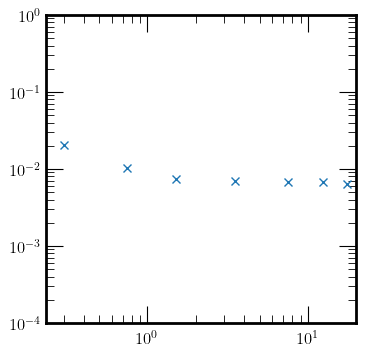

In [90]:


plt.figure(figsize=(4,4))
plt.plot(hadrons_dic2["energy_resolutions"], hadrons_dic2["variance_om"], 'x')
plt.yscale("log")
plt.xscale("log")
plt.xlim([0,20])
plt.ylim([1e-4,1])

In [75]:
# # number_binslen(np.exp(np.arange(np.log(0.5), np.log(60), 1)))
# number_dist = len(hadrons_dic2["distributions_pandora"])
# import seaborn as sns
# for i in range(number_dist):
#     vars_p = np.array(hadrons_dic2["varp_cld"])/np.array(hadrons_dic2["mp_cld"])
#     vars = np.array(hadrons_dic2["var_cld"])/np.array(hadrons_dic2["m_cld"])
#     fig = plt.figure(figsize=(4,4))
#     sns.histplot(hadrons_dic2["distributions_pandora_reco"][i],  bins= np.linspace(-1, 1, 2000), element="step", fill=False, color="red", label=str(vars_p[i]))
#     sns.histplot(hadrons_dic2["distributions_model_reco"][i], bins= np.linspace(-1, 1, 2000), element="step", fill=False, color="blue", label=str(vars[i]))
#     # photons_dic2["distributions_model"]
#     plt.xlim([-0.02,0.02])
#     plt.legend()
    # PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
    # PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")

    # fig.savefig(os.path.join(PATH_store, "hadrons_dic1_"+str(i)+".png"), bbox_inches="tight")


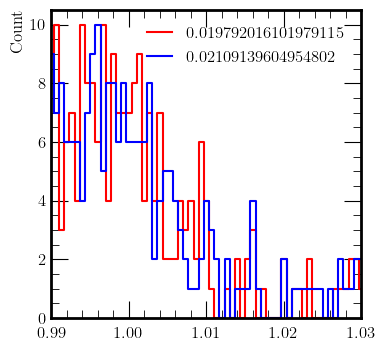

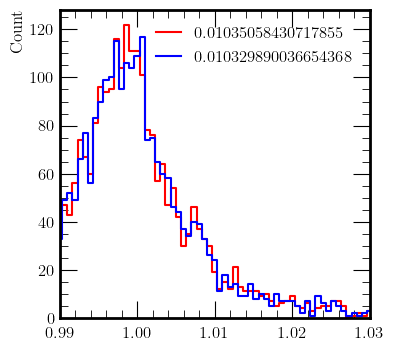

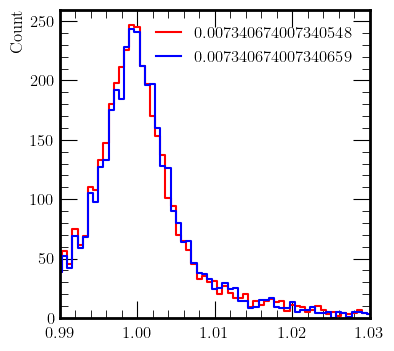

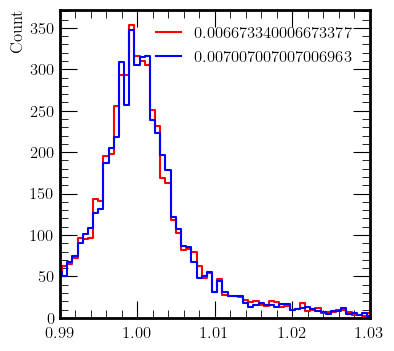

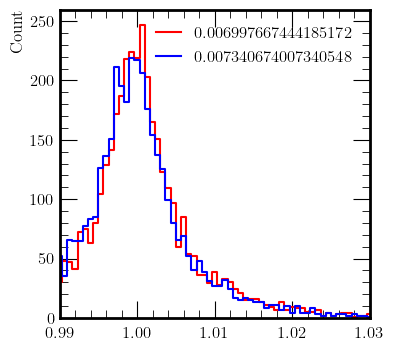

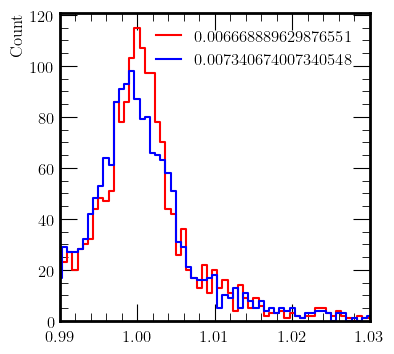

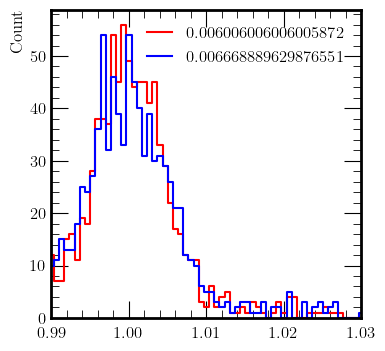

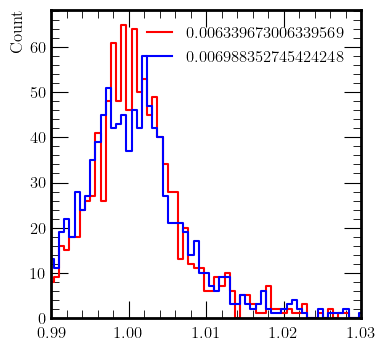

In [13]:
# number_binslen(np.exp(np.arange(np.log(0.5), np.log(60), 1)))
number_dist = len(hadrons_dic2["distributions_pandora"])
import seaborn as sns
for i in range(number_dist):
    vars_p = np.array(hadrons_dic2["variance_om_p"])/np.array(hadrons_dic2["mean_p"])
    vars = np.array(hadrons_dic2["variance_om"])/np.array(hadrons_dic2["mean"])
    fig = plt.figure(figsize=(4,4))
    sns.histplot(hadrons_dic2["distributions_pandora"][i],  bins= np.linspace(0, 2, 3000), element="step", fill=False, color="red", label=str(vars_p[i]))
    sns.histplot(hadrons_dic2["distributions_model"][i], bins= np.linspace(0, 2, 3000), element="step", fill=False, color="blue", label=str(vars[i]))
    # photons_dic2["distributions_model"]
    plt.xlim([0.99,1.03])
    plt.legend()
    PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
    PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")

    fig.savefig(os.path.join(PATH_store, "hadrons_dic1_"+str(i)+".png"), bbox_inches="tight")


In [98]:
matched_[(matched_.pred_pid_matched==2)*(matched_.true_showers_E<0.5)]

,true_showers_E,reco_showers_E,pred_showers_E,e_pred_and_truth,pid,calibration_factor,calibrated_E,step,number_batch,is_track_in_cluster,...,ECAL_hits,HCAL_hits,gen_status,labels,pred_pos_matched,pred_pid_matched,pred_ref_pt_matched,matched_extra_features,true_pos,pid_4_class_true
19,0.114865,0.175000,0.231994,0.175000,11.0,0.231939,0.231939,0.0,13.0,0.0,...,10.0,0.0,0.0,22.0,"[-0.14887076616287231, 0.51808762550354, -0.84...",2.0,"[-411.62310791015625, 1432.496337890625, -2328...","[10.0, 0.5, 0.0, 0.0, 0.3014635145664215, 0.15...","[-0.004866383238392009, 0.08667581781810886, -...",0.0
27,0.222383,0.094840,0.202003,0.094840,22.0,0.202204,0.202204,0.0,14.0,0.0,...,8.0,3.0,0.0,40.0,"[-0.3886883556842804, 0.3119809329509735, 0.86...",2.0,"[-1039.05712890625, 833.9998168945312, 2317.54...","[11.0, 0.5, 0.0, 0.0, 1.5410033464431763, -1.6...","[-0.04463624668726637, 0.12048513484132573, 0....",3.0
2,0.372304,0.406225,0.689275,0.406225,22.0,0.688882,0.688882,0.0,19.0,0.0,...,21.0,0.0,1.0,9.0,"[0.41192543506622314, -0.635163426399231, 0.65...",2.0,"[1210.72265625, -1866.859130859375, 1920.35473...","[21.0, 0.5, 0.0, 0.0, 1.6559538841247559, -1.9...","[0.14760457182803702, -0.2436962350763497, 0.2...",3.0
20,0.336884,0.140103,0.246207,0.140103,11.0,0.245777,0.245777,1.0,32.0,0.0,...,10.0,1.0,0.0,20.0,"[-0.03867460787296295, -0.07252752035856247, 0...",2.0,"[-92.27039337158203, -173.03712463378906, 2377...","[11.0, 0.5, 0.0, 0.0, 1.703608512878418, -1.58...","[-0.10866477651964805, -0.19442286941186998, 0...",0.0
14,0.497382,0.690956,1.321526,0.690956,-211.0,1.320885,1.320885,1.0,37.0,0.0,...,16.0,0.0,0.0,12.0,"[0.6405612826347351, -0.35740888118743896, 0.6...",2.0,"[1692.2886962890625, -944.2328491210938, 1795....","[16.0, 0.5, 0.0, 0.0, 2.6747894287109375, -2.7...","[0.15949120233281813, -0.39486561436088696, 0....",1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12,0.071891,0.021451,0.182688,0.021451,22.0,0.182834,0.182834,494.0,9885.0,0.0,...,3.0,2.0,1.0,26.0,"[-0.5790538787841797, 0.5657937526702881, 0.58...",2.0,"[-1601.8262939453125, 1565.1448974609375, 1623...","[5.0, 0.5, 0.0, 0.0, 2.1265628337860107, -2.39...","[-0.04184690098625476, 0.04112128056263883, 0....",3.0
22,0.194422,0.138944,0.448181,0.138944,22.0,0.447919,0.447919,494.0,9888.0,0.0,...,21.0,0.0,0.0,19.0,"[0.3888525366783142, -0.20816649496555328, 0.8...",2.0,"[1005.795654296875, -538.4379272460938, 2321.3...","[21.0, 0.5, 0.0, 0.0, 0.6252968311309814, -0.4...","[0.018907988178384315, -0.09475845963027246, 0...",3.0
20,0.361844,0.351828,0.503291,0.351828,-11.0,0.503008,0.503008,494.0,9890.0,0.0,...,21.0,0.0,0.0,18.0,"[0.3462052047252655, 0.03497228026390076, 0.93...",2.0,"[860.522705078125, 86.92659759521484, 2330.253...","[21.0, 0.5, 0.0, 0.0, 0.4902443289756775, -0.1...","[0.31472747028837905, 0.0546951131770374, 0.16...",0.0
29,0.198758,0.206836,0.324217,0.200099,22.0,0.324062,0.324062,494.0,9894.0,0.0,...,15.0,4.0,0.0,28.0,"[0.6063857078552246, -0.21853457391262054, -0....",2.0,"[1846.824951171875, -665.5748901367188, -2328....","[19.0, 0.5, 0.0, 0.0, 2.126319408416748, -2.17...","[0.11465226370515529, 0.04841847805477062, -0....",3.0


In [112]:
df = matched_[(matched_.pred_pid_matched==2)*(matched_.true_showers_E<0.5)]
mask = df.calibrated_E/df.true_showers_E<0.4
df[mask]

,true_showers_E,reco_showers_E,pred_showers_E,e_pred_and_truth,pid,calibration_factor,calibrated_E,step,number_batch,is_track_in_cluster,...,ECAL_hits,HCAL_hits,gen_status,labels,pred_pos_matched,pred_pid_matched,pred_ref_pt_matched,matched_extra_features,true_pos,pid_4_class_true
16,0.393987,0.133623,0.133623,0.133623,-211.0,0.134005,0.134005,32.0,642.0,0.0,...,3.0,1.0,0.0,17.0,"[-0.24859388172626495, -0.09301513433456421, -...",2.0,"[-610.2971801757812, -228.35183715820312, -236...","[4.0, 0.5, 0.0, 0.0, 0.7101312875747681, -0.78...","[0.02798848464910905, 0.22758728064022546, -0....",1.0
2,0.482360,0.158919,0.191638,0.158919,-211.0,0.191889,0.191889,62.0,1249.0,0.0,...,7.0,1.0,1.0,20.0,"[-0.04647145792841911, -0.0638732984662056, -0...",2.0,"[-116.03791046142578, -159.4898223876953, -248...","[8.0, 0.5, 0.0, 0.0, 0.5418086051940918, -0.43...","[-0.4042886081363025, 0.0076793593216269475, -...",1.0
14,0.357075,0.127053,0.127053,0.127053,22.0,0.127185,0.127185,70.0,1404.0,0.0,...,2.0,2.0,1.0,19.0,"[0.17513257265090942, -0.29159876704216003, 0....",2.0,"[430.3811340332031, -716.5919799804688, 2310.9...","[4.0, 0.5, 0.0, 0.0, 1.2917888164520264, -1.28...","[0.06359307847591004, -0.10360182851857294, 0....",3.0
71,0.440337,0.139375,0.160834,0.139375,211.0,0.161000,0.161000,88.0,1768.0,0.0,...,3.0,4.0,0.0,30.0,"[0.04196927696466446, -0.14278621971607208, 0....",2.0,"[104.01670837402344, -353.8815612792969, 2450....","[7.0, 0.5, 0.0, 0.0, 1.2141789197921753, -1.18...","[0.29296394213861876, 0.08137391720635254, 0.2...",1.0
11,0.427909,0.162033,0.169778,0.162033,211.0,0.170060,0.170060,93.0,1871.0,0.0,...,1.0,3.0,1.0,32.0,"[-0.3765186369419098, 0.08631739020347595, -0....",2.0,"[-955.0744018554688, 218.9520721435547, -2339....","[4.0, 0.5, 0.0, 0.0, 0.6697914004325867, -0.88...","[-0.32822003685615825, -0.04798905896726896, -...",1.0
12,0.423286,0.142884,0.142884,0.142884,211.0,0.143318,0.143318,96.0,1924.0,0.0,...,0.0,3.0,1.0,18.0,"[0.023148639127612114, -0.14622056484222412, 0...",2.0,"[61.56622314453125, -388.88885498046875, 2630....","[3.0, 0.5, 0.0, 0.0, 0.2598268389701843, 0.145...","[0.14482260780566464, -0.2932632293416283, 0.2...",1.0
4,0.453714,0.137270,0.145897,0.137270,-211.0,0.146090,0.146090,144.0,2899.0,0.0,...,1.0,3.0,1.0,24.0,"[-0.0033238432370126247, 0.38707950711250305, ...",2.0,"[-8.361515045166016, 973.74365234375, -2319.5]","[4.0, 0.5, 0.0, 0.0, 0.523711085319519, -0.665...","[0.29149661739631916, 0.2238579525239274, -0.2...",1.0
14,0.381256,0.102844,0.102844,0.102844,211.0,0.102806,0.102806,184.0,3695.0,0.0,...,5.0,1.0,0.0,27.0,"[0.11274451017379761, -0.17472422122955322, 0....",2.0,"[268.6120300292969, -416.2777404785156, 2330.4...","[6.0, 0.5, 0.0, 0.0, 0.5366847515106201, -0.17...","[0.09966093157792347, 0.234326284904293, 0.247...",1.0
3,0.340300,0.088760,0.088760,0.088760,-211.0,0.088891,0.088891,211.0,4229.0,0.0,...,2.0,2.0,1.0,14.0,"[0.20231366157531738, -0.04367333650588989, 0....",2.0,"[494.5521545410156, -106.7586898803711, 2391.5...","[4.0, 0.5, 0.0, 0.0, 0.3657877743244171, 0.260...","[-0.12593017041202434, 0.007720132057562889, 0...",1.0
7,0.342750,0.092981,0.092981,0.092981,211.0,0.093178,0.093178,211.0,4237.0,0.0,...,0.0,4.0,1.0,19.0,"[0.08724375814199448, -0.1264990270137787, -0....",2.0,"[237.20933532714844, -343.9414978027344, -2686...","[4.0, 0.5, 0.0, 0.0, 0.0905456393957138, -0.04...","[0.22178900066890977, -0.0286304167427693, -0....",1.0


In [92]:
print("PID:neutron___________________________________________")
# matched_pandora_n = sd_pandora1[(np.abs(sd_pandora1.pid_4_class_true)==2)]
# matched_n = sd_hgb1[(np.abs(sd_hgb1.pid_4_class_true)==2)]
# matched_pandora_neutral = matched_pandora_n[(matched_pandora_h.pandora_pid==2112)*(matched_n.pred_pid_matched==2)]
# matched_neutral = matched_n[(matched_n.pred_pid_matched==2)*(matched_pandora_h.pandora_pid==2112)]
matched_pandora = sd_pandora1
matched_ = sd_hgb1
mask = (matched_.pred_pid_matched==2)*(matched_.true_showers_E<0.5)
matched_.loc[mask, "calibrated_E"] =matched_[(matched_.pred_pid_matched==2)*(matched_.true_showers_E<0.5)].pred_showers_E
neutrons = get_response_for_id_i(
    [2112], matched_pandora[np.abs(matched_pandora.pandora_pid)==2112], matched_[matched_.pred_pid_matched==2], tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid,pandora=pandora
)

# neutrons = get_response_for_id_i(
#     [2112], matched_pandora_neutral, matched_neutral, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid,pandora=pandora
# )

PID:neutron___________________________________________


/tmp/mgarciam/ipykernel_2328056/3415099919.py:8: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  mask = (matched_.pred_pid_matched==2)*(matched_.true_showers_E<0.5)
/tmp/mgarciam/ipykernel_2328056/3415099919.py:9: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  matched_.loc[mask, "calibrated_E"] =matched_[(matched_.pred_pid_matched==2)*(matched_.true_showers_E<0.5)].pred_showers_E
/tmp/mgarciam/ipykernel_2328056/1869595698.py:74: RuntimeWarning: invalid value encountered in sqrt
  pred_pxyz = np.sqrt(p_squared).reshape(-1, 1) * pred_pxyz


number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500
number_bins 500


In [19]:
df = matched_pandora[(np.abs(matched_pandora.pandora_pid)==2112)*(matched_pandora.true_showers_E>15)*(matched_pandora.true_showers_E<20)]
df_more = df[(df.true_showers_E/df.pandora_calibrated_pfo)>1.2]
df_less = df[((df.true_showers_E/df.pandora_calibrated_pfo)<1.2)*((df.true_showers_E/df.pandora_calibrated_pfo)>1)]

/tmp/mgarciam/ipykernel_1606522/1499494672.py:1: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  df = matched_pandora[(np.abs(matched_pandora.pandora_pid)==2112)*(matched_pandora.true_showers_E>15)*(matched_pandora.true_showers_E<20)]


/tmp/mgarciam/ipykernel_1606522/1794955186.py:1: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  df = matched_pandora[(np.abs(matched_pandora.pandora_pid)==2112)*(matched_pandora.true_showers_E>15)*(matched_pandora.true_showers_E<20)]


Text(0.5, 1.0, '15-20')

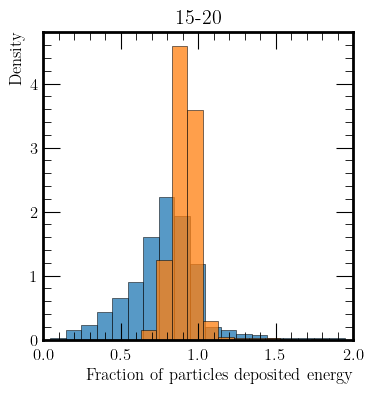

In [31]:
df = matched_pandora[(np.abs(matched_pandora.pandora_pid)==2112)*(matched_pandora.true_showers_E>15)*(matched_pandora.true_showers_E<20)]
df_more = df[(df.true_showers_E/df.pandora_calibrated_pfo)>1.2]
df_less = df[((df.true_showers_E/df.pandora_calibrated_pfo)<1.2)*((df.true_showers_E/df.pandora_calibrated_pfo)>1)]
import seaborn as sns
plt.figure(figsize=(4,4))
sns.histplot(df_more.pred_showers_E.values/ df_more.reco_showers_E.values, binwidth=0.1, stat="density")
sns.histplot(df_less.pred_showers_E.values/ df_less.reco_showers_E.values, binwidth=0.1, stat="density")
plt.xlim([0,2])
plt.xlabel("Fraction of particles deposited energy")
plt.title("15-20")

In [59]:
df_he = matched_pandora[(np.abs(matched_pandora.pandora_pid)==2112)*(matched_pandora.true_showers_E>20)*(matched_pandora.true_showers_E<60)]
# df_more = df[(df.pandora_calibrated_pfo/df.true_showers_E)>1.5]
# df_less = df[((df.pandora_calibrated_pfo/df.true_showers_E)<1.5)*((df.pandora_calibrated_pfo/df.true_showers_E)>1)]
# import seaborn as sns
# plt.figure(figsize=(4,4))
# sns.histplot(df_more.pred_showers_E.values/ df_more.reco_showers_E.values, binwidth=0.05, stat="density",  label="20-60 bad", element="step", fill=False)
# sns.histplot(df_less.pred_showers_E.values/ df_less.reco_showers_E.values, binwidth=0.05, stat="density",  label="20-60 good", element="step", fill=False)
# df_more[(df_more.pred_showers_E.values/ df_more.reco_showers_E.values)>1.5]
# print(len(df_more)/ len(df_less))
df_me = matched_pandora[(np.abs(matched_pandora.pandora_pid)==2112)*(matched_pandora.true_showers_E>10)*(matched_pandora.true_showers_E<15)]
# df_more = df[(df.pandora_calibrated_pfo/df.true_showers_E)>1.5]
# df_less = df[((df.pandora_calibrated_pfo/df.true_showers_E)<1.5)*((df.pandora_calibrated_pfo/df.true_showers_E)>1)]
# sns.histplot(df_more.pred_showers_E.values/ df_more.reco_showers_E.values, binwidth=0.05, stat="density", label="10-15 bad", element="step", fill=False)
# sns.histplot(df_less.pred_showers_E.values/ df_less.reco_showers_E.values, binwidth=0.05, stat="density", label="10-15 good", element="step", fill=False)
# df_more[(df_more.pred_showers_E.values/ df_more.reco_showers_E.values)>1.5]
# print(len(df_more)/ len(df_less))
# df = matched_pandora[(np.abs(matched_pandora.pandora_pid)==2112)*(matched_pandora.true_showers_E>5)*(matched_pandora.true_showers_E<10)]
# df_more = df[(df.pandora_calibrated_pfo/df.true_showers_E)>1.5]
# df_less = df[((df.pandora_calibrated_pfo/df.true_showers_E)<1.5)*((df.pandora_calibrated_pfo/df.true_showers_E)>1)]
# sns.histplot(df_more.pred_showers_E.values/ df_more.reco_showers_E.values, binwidth=0.05, stat="density", label="5-10 bad", element="step", fill=False)
# sns.histplot(df_less.pred_showers_E.values/ df_less.reco_showers_E.values, binwidth=0.05, stat="density", label="5-10 good", element="step", fill=False)
# plt.xlim([0,2])
# plt.xlabel("Fraction of particles deposited energy")
# plt.legend()
# print(len(df_more)/ len(df_less))

/tmp/mgarciam/ipykernel_1606522/684255314.py:1: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  df_he = matched_pandora[(np.abs(matched_pandora.pandora_pid)==2112)*(matched_pandora.true_showers_E>20)*(matched_pandora.true_showers_E<60)]
/tmp/mgarciam/ipykernel_1606522/684255314.py:10: UserWarning: evaluating in Python space because the '*' operator is not supported by numexpr for the bool dtype, use '&' instead.
  df_me = matched_pandora[(np.abs(matched_pandora.pandora_pid)==2112)*(matched_pandora.true_showers_E>10)*(matched_pandora.true_showers_E<15)]


In [89]:
# np.argmax(df_he.reco_showers_E.values-df_he.pred_showers_E.values)
# df_he[11940]

print(np.argmax(np.abs(df_me.reco_showers_E.values-df_me.pred_showers_E.values)))
mask = np.abs(df_me.reco_showers_E.values-df_me.pred_showers_E.values)>15
df_me[mask]

12504


,true_showers_E,reco_showers_E,pred_showers_E,e_pred_and_truth,pandora_calibrated_E,pandora_calibrated_pfo,pandora_calibrated_pos,pandora_ref_pt,pid,pandora_pid,...,is_track_correct,is_track_in_MC,distance_to_cluster_MC,vertex,ECAL_hits,HCAL_hits,labels,gen_status,true_pos,pid_4_class_true
14,10.865525,11.116435,26.591862,10.636676,30.150185,30.150185,"[21.224681854248047, -17.038084030151367, 12.9...","[1992.046630859375, -1586.2032470703125, 1210....",22.0,2112.0,...,0.0,0,0.000000,"[-0.013291282326014724, 0.7147035425595637, 10...",346.0,148.0,31.0,1.0,"[7.643558907717551, -6.139571005626338, 4.6841...",3.0
0,12.011097,12.439083,43.690441,11.829133,46.029289,46.029289,"[-3.733642101287842, 45.443485260009766, 6.293...","[-68.27478790283203, 2695.84521484375, 335.327...",-2112.0,2112.0,...,0.0,0,0.000000,"[0.21522169979977698, -0.21443247922421865, -3...",297.0,364.0,7.0,1.0,"[-0.9879130633638735, 11.792447633938744, 1.82...",2.0
21,10.571813,9.658332,28.060743,8.648948,31.957033,31.957033,"[17.733753204345703, 23.202486038208008, -12.9...","[1552.69140625, 2124.935302734375, -1115.22668...",211.0,2112.0,...,0.0,0,0.000000,"[655.4435886180553, 893.750040540367, -502.246...",294.0,215.0,17.0,1.0,"[5.799739530141318, 7.770175471994527, -4.2108...",1.0
13,13.553032,13.455477,28.918158,13.110842,32.724556,32.724556,"[-0.752601683139801, 8.155060768127441, 31.682...","[-222.28948974609375, 715.4978637695312, 2753....",130.0,2112.0,...,0.0,0,0.000000,"[1.2887243804025525, -0.3422888528595457, 34.4...",333.0,207.0,12.0,1.0,"[-0.8245092808995396, 3.5645101400792507, 13.0...",2.0
4,14.778225,16.101963,32.548885,15.627600,36.322300,36.322300,"[34.062034606933594, -11.12784481048584, -5.94...","[2611.631591796875, -658.81298828125, -435.365...",-2112.0,2112.0,...,0.0,0,0.000000,"[-0.2454669705320966, 0.5078448844311889, 0.48...",593.0,215.0,17.0,1.0,"[14.05796845546478, -3.9610715960572733, -2.04...",2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,12.327525,13.025424,31.216829,12.421306,32.612625,32.612625,"[-26.107254028320312, -8.463507652282715, 17.6...","[-2337.9033203125, -708.7440185546875, 1625.23...",-2112.0,2112.0,...,0.0,0,0.000000,"[-0.1216254761305672, -0.27869242030293345, -4...",607.0,136.0,10.0,1.0,"[-9.692980810976104, -2.8125567512552667, 7.01...",2.0
0,12.964194,11.531635,26.929617,10.408297,31.483118,31.483118,"[10.98193073272705, 25.52805519104004, 14.7953...","[961.7122192382812, 2381.046630859375, 1346.41...",-321.0,2112.0,...,0.0,1,0.120238,"[0.7676454161685976, -0.4921885651063561, 90.7...",315.0,244.0,23.0,1.0,"[4.63484875125417, 10.732654421590134, 5.58165...",1.0
12,10.221598,8.347397,23.525480,6.975735,26.533226,26.533226,"[-4.074209690093994, 2.0670151710510254, -26.1...","[-479.3340148925781, 135.3621826171875, -2871....",211.0,2112.0,...,0.0,1,0.146699,"[0.255877020456387, -0.2786407197619072, -39.7...",150.0,194.0,11.0,1.0,"[-1.5770624838419771, 0.5819256981074309, -10....",1.0
10,10.611438,10.521126,26.120146,9.452081,29.848627,29.848627,"[-4.470596790313721, -29.231462478637695, 4.05...","[-431.988037109375, -2497.334228515625, 326.76...",-211.0,2112.0,...,0.0,2,0.142880,"[-0.4370593166704311, 0.11249320812148114, -24...",309.0,186.0,21.0,1.0,"[-2.2330097082167772, -10.253943481318695, 1.5...",1.0


In [86]:
519/100

5.19

In [74]:
df_he[11940:11941]

,true_showers_E,reco_showers_E,pred_showers_E,e_pred_and_truth,pandora_calibrated_E,pandora_calibrated_pfo,pandora_calibrated_pos,pandora_ref_pt,pid,pandora_pid,...,is_track_correct,is_track_in_MC,distance_to_cluster_MC,vertex,ECAL_hits,HCAL_hits,labels,gen_status,true_pos,pid_4_class_true
8,25.656586,35.025135,6.368118,6.368118,8.03532,8.03532,"[4.475253105163574, -3.4235875606536865, -5.72...","[2349.04150390625, -1528.8651123046875, -3043....",-2212.0,2112.0,...,0.0,1,0.138261,"[0.2699812798934222, 0.022824569975992717, -13...",0.0,77.0,16.0,1.0,"[13.301881081944412, -10.562605169049718, -19....",1.0


In [90]:
matched_pandora[matched_pandora.number_batch==519]

,true_showers_E,reco_showers_E,pred_showers_E,e_pred_and_truth,pandora_calibrated_E,pandora_calibrated_pfo,pandora_calibrated_pos,pandora_ref_pt,pid,pandora_pid,...,is_track_correct,is_track_in_MC,distance_to_cluster_MC,vertex,ECAL_hits,HCAL_hits,labels,gen_status,true_pos,pid_4_class_true
0,12.011097,12.439083,43.690441,11.829133,46.029289,46.029289,"[-3.733642101287842, 45.443485260009766, 6.293...","[-68.27478790283203, 2695.84521484375, 335.327...",-2112.0,2112.0,...,0.0,0,0.000000,"[0.21522169979977698, -0.21443247922421865, -3...",297.0,364.0,7.0,1.0,"[-0.9879130633638735, 11.792447633938744, 1.82...",2.0
1,1.800256,1.397321,1.241543,1.241543,1.803749,1.803749,"[-0.33196648955345154, -1.5618737936019897, -0...","[-6.970305919647217, -35.260005950927734, -53....",-211.0,-211.0,...,1.0,1,0.157512,"[0.21522169979977698, -0.21443247922421865, -3...",39.0,11.0,1.0,1.0,"[-0.33062534958060685, -1.5580623595682115, -0...",1.0
2,3.244930,4.655636,4.346263,4.320513,3.252914,3.252914,"[0.7250798344612122, -3.1669909954071045, -0.0...","[8.128837585449219, -35.260005950927734, -36.0...",211.0,211.0,...,1.0,1,0.083294,"[0.21522169979977698, -0.21443247922421865, -3...",53.0,12.0,8.0,1.0,"[0.7251123119084341, -3.158734401291998, -0.08...",1.0
3,21.521553,21.964048,NaN,NaN,NaN,NaN,"[nan, nan, nan]","[nan, nan, nan]",2212.0,NaN,...,0.0,2,0.104188,"[0.21522169979977698, -0.21443247922421865, -3...",NaN,NaN,7.0,1.0,"[-1.4771265449453517, 21.22682870075388, 3.088...",1.0
4,10.365170,12.063151,NaN,NaN,NaN,NaN,"[nan, nan, nan]","[nan, nan, nan]",211.0,NaN,...,0.0,2,0.104310,"[0.21522169979977698, -0.21443247922421865, -3...",NaN,NaN,7.0,1.0,"[-0.47602754291606164, 10.28336954486781, 1.20...",1.0
5,3.038319,2.736630,2.648156,2.648156,2.695210,2.695210,"[-0.042191922664642334, -2.659771680831909, -0...","[-33.54631423950195, -2201.5927734375, -359.73...",22.0,22.0,...,0.0,0,0.000000,"[0.21522170524350356, -0.21443952183445014, -3...",97.0,0.0,4.0,1.0,"[-0.04850869221615426, -3.005410395821273, -0....",3.0
6,2.231673,2.469831,2.379106,2.317519,2.421383,2.421383,"[0.055708419531583786, -2.400878667831421, -0....","[52.9072380065918, -2219.937744140625, -285.31...",22.0,22.0,...,0.0,0,0.000000,"[0.21522170524350356, -0.21443952183445014, -3...",86.0,0.0,9.0,1.0,"[0.05254534508030433, -2.2168527732966674, -0....",3.0
7,4.138870,4.268361,3.959279,3.843672,4.029633,4.029633,"[0.532127320766449, -3.916138172149658, -0.786...","[299.4468688964844, -2219.051513671875, -447.6...",22.0,22.0,...,0.0,0,0.000000,"[0.2154689420852286, -0.21625392854392614, -35...",129.0,0.0,11.0,1.0,"[0.5449104862700533, -4.03451703449783, -0.745...",3.0
8,11.270583,11.973410,11.723207,11.453428,11.931576,11.931576,"[1.582977056503296, -11.637939453125, -2.10092...","[304.4375305175781, -2240.710205078125, -404.1...",22.0,22.0,...,0.0,0,0.000000,"[0.2154689420852286, -0.21625392854392614, -35...",320.0,0.0,11.0,1.0,"[1.4989385101543014, -11.022645850571761, -1.8...",3.0
9,5.602102,4.921616,4.592067,4.425429,5.617921,5.617921,"[0.3602651357650757, -5.525002956390381, -0.94...","[2.5669069290161133, -35.2599983215332, -41.10...",-211.0,-211.0,...,1.0,1,0.139094,"[0.21522169979977698, -0.21443247922421865, -3...",99.0,22.0,11.0,1.0,"[0.35939565187140277, -5.509601600780268, -0.9...",1.0


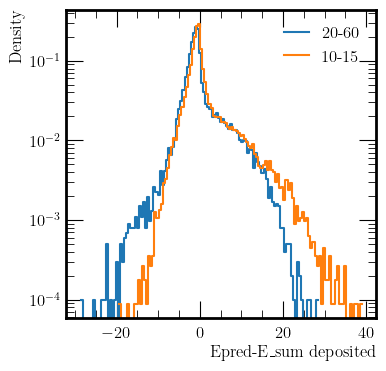

In [79]:

fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot()
sns.histplot(df_he.pred_showers_E - df_he.reco_showers_E, binwidth=0.5, stat="density",  label="20-60", element="step", fill=False)
sns.histplot(df_me.pred_showers_E - df_me.reco_showers_E, binwidth=0.5, stat="density",  label="10-15", element="step", fill=False)
plt.legend()
plt.xlabel("Epred-E_sum deposited")
ax.set_yscale('log')

In [54]:
np.sum(df_more[(df_more.pred_showers_E.values/ df_more.reco_showers_E.values)>1.5].is_track_in_MC.values)/len(df_more[(df_more.pred_showers_E.values/ df_more.reco_showers_E.values)>1.5].is_track_in_MC.values)

0.4939582570487001

In [58]:
matched_pandora[matched_pandora.number_batch==2]

,true_showers_E,reco_showers_E,pred_showers_E,e_pred_and_truth,pandora_calibrated_E,pandora_calibrated_pfo,pandora_calibrated_pos,pandora_ref_pt,pid,pandora_pid,...,is_track_correct,is_track_in_MC,distance_to_cluster_MC,vertex,ECAL_hits,HCAL_hits,labels,gen_status,true_pos,pid_4_class_true
0,1.036974,0.759764,0.731689,0.731689,1.036582,1.036582,"[0.6093882322311401, 0.6182500123977661, 0.549...","[9.210142135620117, 9.542329788208008, -2.7951...",-211.0,-211.0,...,1.0,1,0.141543,"[-0.15125353989006465, -0.024714538260942755, ...",46.0,0.0,10.0,1.0,"[0.610487936705855, 0.6177536739685775, 0.5491...",1.0
1,10.484183,9.282381,8.468991,8.468987,10.466969,10.466969,"[6.793567657470703, 5.8889241218566895, 5.3577...","[10.79338550567627, 9.444071769714355, -2.6330...",211.0,211.0,...,1.0,1,0.103223,"[-0.15125353989006465, -0.024714538260942755, ...",302.0,13.0,25.0,1.0,"[6.806279444182316, 5.897718613810588, 5.36563...",1.0
2,16.479012,18.137205,17.895201,17.813490,16.454649,16.454649,"[10.682465553283691, 9.838995933532715, 7.7340...","[9.698607444763184, 9.053860664367676, -4.1233...",-211.0,-211.0,...,1.0,1,0.117605,"[-0.15125353989006465, -0.024714538260942755, ...",35.0,155.0,8.0,1.0,"[10.699371682984124, 9.853780026059837, 7.7436...",1.0
3,3.401830,3.685895,2.699715,2.619765,3.407809,3.407809,"[2.3719780445098877, 2.0333292484283447, 1.353...","[10.051346778869629, 8.701111793518066, -5.445...",211.0,211.0,...,1.0,2,0.155074,"[-0.15125353989006465, -0.024714538260942755, ...",81.0,11.0,5.0,1.0,"[2.36737822533628, 2.030834279178815, 1.350628...",1.0
4,1.722077,1.277732,1.220653,1.220653,1.652390,1.652390,"[-1.175327181816101, -1.0154238939285278, -0.5...","[-27.322389602661133, -23.196216583251953, -23...",321.0,211.0,...,1.0,1,0.149092,"[-0.15125353989006465, -0.024714538260942755, ...",51.0,2.0,3.0,1.0,"[-1.176118400342622, -1.0172954427654957, -0.5...",1.0
5,3.146025,3.461888,1.528155,1.528155,3.131648,3.131648,"[2.3285045623779297, 1.6317895650863647, 1.305...","[11.112814903259277, 7.821343421936035, -4.957...",211.0,211.0,...,1.0,1,0.060789,"[-0.15125215395107414, -0.024713515732297044, ...",53.0,0.0,22.0,1.0,"[2.3413525359050213, 1.6357699090303335, 1.311...",1.0
6,1.804954,1.726059,1.718119,1.718119,1.799543,1.799543,"[1.2714735269546509, 1.0093228816986084, 0.763...","[27.75821304321289, 22.441328048706055, 5.5897...",-211.0,-211.0,...,1.0,1,0.128903,"[-0.15125215395107414, -0.024713515732297044, ...",39.0,20.0,7.0,1.0,"[1.2755064499623683, 1.014434618506028, 0.7631...",1.0
7,1.405592,1.105150,0.758878,0.758878,1.404453,1.404453,"[0.941502034664154, 0.6551684737205505, 0.7983...","[11.98022747039795, 8.47099494934082, -0.95390...",-211.0,-211.0,...,1.0,1,0.112305,"[-0.15125353989006465, -0.024714538260942755, ...",35.0,0.0,18.0,1.0,"[0.9431555859833601, 0.6549757177946266, 0.798...",1.0
8,1.012907,1.007088,0.971729,0.971729,1.011377,1.011377,"[0.5335581302642822, 0.8197129964828491, 0.216...","[19.482728958129883, 29.466373443603516, -3.39...",211.0,211.0,...,1.0,1,0.067616,"[-0.15125353989006465, -0.024714538260942755, ...",31.0,0.0,4.0,1.0,"[0.5335805218862651, 0.8212322964080884, 0.217...",1.0
9,0.371078,0.121757,NaN,NaN,NaN,NaN,"[nan, nan, nan]","[nan, nan, nan]",-211.0,NaN,...,0.0,1,NaN,"[-0.15125353989006465, -0.024714538260942755, ...",NaN,NaN,0.0,1.0,"[-0.013746952045278992, -0.10001650892851041, ...",1.0


In [57]:
df_more.number_batch

12        2.0
0        12.0
5        24.0
17       73.0
1       154.0
       ...   
0     88875.0
2     88889.0
12    88987.0
10    89023.0
2     89026.0
Name: number_batch, Length: 3703, dtype: float64

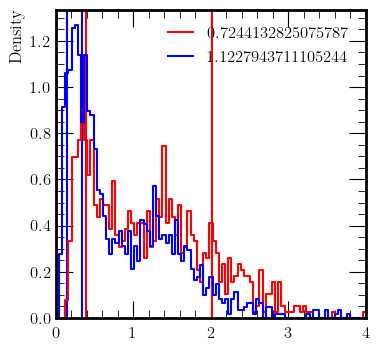

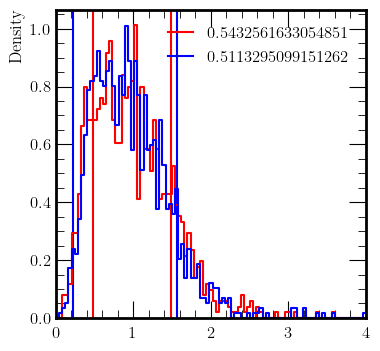

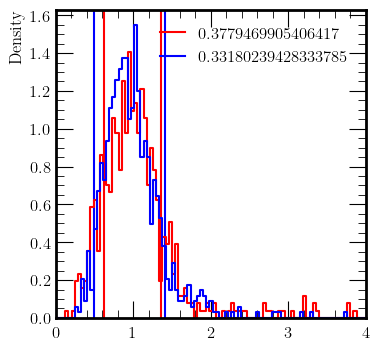

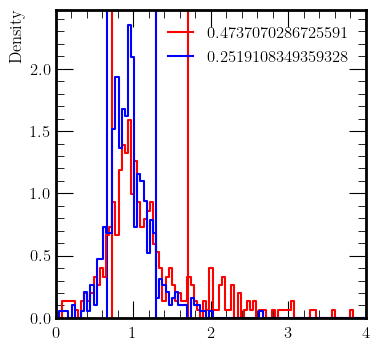

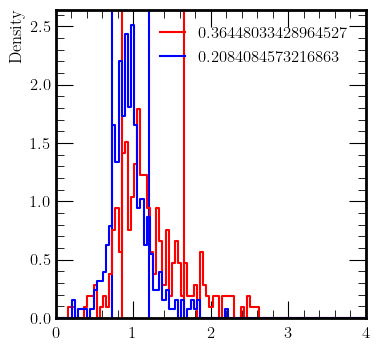

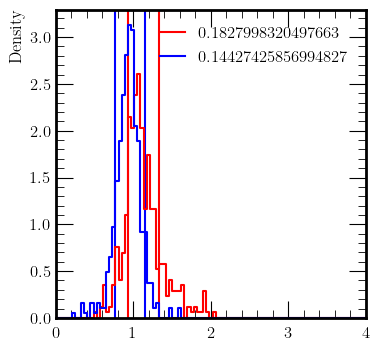

In [111]:
# number_binslen(np.exp(np.arange(np.log(0.5), np.log(60), 1)))
number_dist = len(neutrons["distributions_pandora"])
import seaborn as sns
for i in range(number_dist):
    p16p = np.percentile(neutrons["distributions_pandora"][i], 16)
    p84p = np.percentile(neutrons["distributions_pandora"][i], 84)
    p16 = np.percentile(neutrons["distributions_model"][i], 16)
    p84 = np.percentile(neutrons["distributions_model"][i], 84)
    vars_p = 0.5*np.array(neutrons["variance_om_p"]) / np.array(neutrons["mean_p"])
    vars = 0.5*np.array(neutrons["variance_om"]) / np.array(neutrons["mean"])
    fig = plt.figure(figsize=(4,4))
    plt.axvline(x=p16p, color='r', linestyle='-',)
    plt.axvline(x=p84p, color='r', linestyle='-',)
    plt.axvline(x=p16, color='b', linestyle='-',)
    plt.axvline(x=p84, color='b', linestyle='-',)
    sns.histplot(neutrons["distributions_pandora"][i], stat="density", bins= np.linspace(0, 4, 100), element="step", fill=False, color="red", label=str(vars_p[i]))
    sns.histplot(neutrons["distributions_model"][i+1], stat="density", bins= np.linspace(0, 4, 100), element="step", fill=False, color="blue", label=str(vars[i+1]))
    # photons_dic2["distributions_model"]
    plt.xlim([0,4])
    plt.legend()
    PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
    PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")

    fig.savefig(os.path.join(PATH_store, "neutrons1_"+str(i)+".png"), bbox_inches="tight")

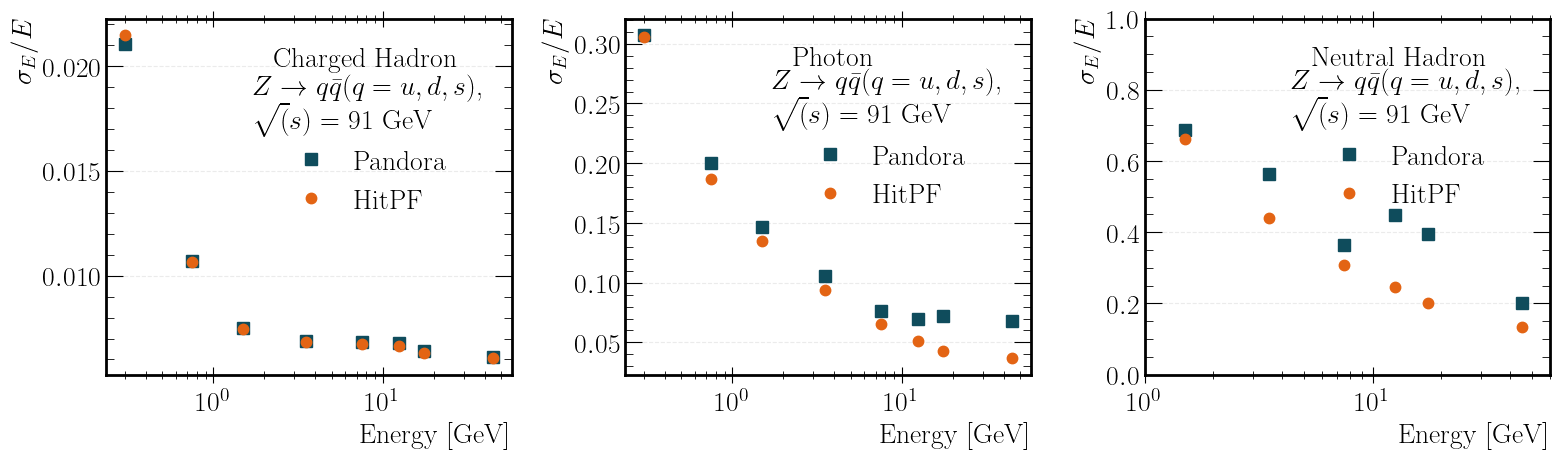

In [99]:
### E resolution with PID
photon_edir = photons_dic
ch_edir = hadrons_dic2
nh_edir = neutrons
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
size_font = 20

STYLE_OURS = dict(color="#E36414",  marker='.', linestyle='None', markersize=15) #lw=2.5, 
STYLE_PANDORA = dict(color="#0F4C5C" ,  marker='s', linestyle='None', markersize=8)
fig, ax_eff = plt.subplots(1, 3,figsize=(16, 5))
bins = [0, 5, 15, 50]
bin_labels = [f"[{bins[i]},{bins[i + 1]}]" for i in range(len(bins) - 1)]
ax_eff[1].plot(photon_edir["energy_resolutions_p"], 0.5*np.array(photon_edir["variance_om_p"]) / np.array(photon_edir["mean_p"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[0].plot(photon_edir["energy_resolutions"], photon_edir["variance_om_baseline"] / photon_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[1].plot(photon_edir["energy_resolutions"],0.5*np.array(photon_edir["variance_om"]) / np.array(photon_edir["mean"]), label="HitPF", **STYLE_OURS)
ax_eff[1].set_xlabel("Energy [GeV]")
ax_eff[1].set_ylabel("$\sigma_E / E$")
ax_eff[1].set_xticks([2.5, 10.0, 33.0])
ax_eff[1].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[1].tick_params(axis='x', which='both', direction='inout')
ax_eff[1].legend(fontsize = size_font, title_fontsize=size_font, title=r"Photon \\ $Z\rightarrow q \bar q (q=u,d,s)$, \\ $\sqrt(s)=$ 91 GeV", loc="upper right")
ax_eff[0].plot(ch_edir["energy_resolutions_p"], 0.5*np.array(ch_edir["variance_om_p"]) / np.array(ch_edir["mean_p"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[1].plot(ch_edir["energy_resolutions"], ch_edir["variance_om_baseline"] / ch_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[0].plot(ch_edir["energy_resolutions"],0.5*np.array(ch_edir["variance_om"])/ np.array(ch_edir["mean"]), label="HitPF", **STYLE_OURS)
ax_eff[0].set_xlabel("Energy [GeV]")
ax_eff[0].set_ylabel("$\sigma_E / E$")
ax_eff[0].set_xticks([2.5, 10.0, 33.0])
ax_eff[0].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[0].tick_params(axis='x', which='both', direction='inout')
ax_eff[0].legend(fontsize = size_font, title_fontsize=size_font, title=r"Charged Hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$,\\  $\sqrt(s)=$ 91 GeV", loc="upper right")


ax_eff[2].plot(nh_edir["energy_resolutions_p"], 0.5*np.array(nh_edir["variance_om_p"]) / np.array(nh_edir["mean_p"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[2].plot(nh_edir["energy_resolutions"], nh_edir["variance_om_baseline"] / nh_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[2].plot(nh_edir["energy_resolutions"],0.5*np.array(nh_edir["variance_om"]) / np.array(nh_edir["mean"]), label="HitPF", **STYLE_OURS)
ax_eff[2].set_xlabel("Energy [GeV]")
ax_eff[2].set_ylabel("$\sigma_E / E$")
ax_eff[2].set_xticks([2.5, 10.0, 33.0])
ax_eff[2].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[2].tick_params(axis='x', which='both', direction='inout')
ax_eff[2].legend(fontsize = size_font, title_fontsize=size_font, title=r"Neutral Hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$, \\ $\sqrt(s)=$ 91 GeV", loc="upper right")
ax_eff[2].set_xlim([1,60])
ax_eff[2].set_ylim([0,1])
size_font  =20
for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    # ax.legend(fontsize = size_font)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)
    # ax.set_xlim([0.5,70])
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font
fig.tight_layout()
fig.savefig(os.path.join(PATH_store, "e_resolution_more_data_v05_v2.pdf"), bbox_inches="tight")


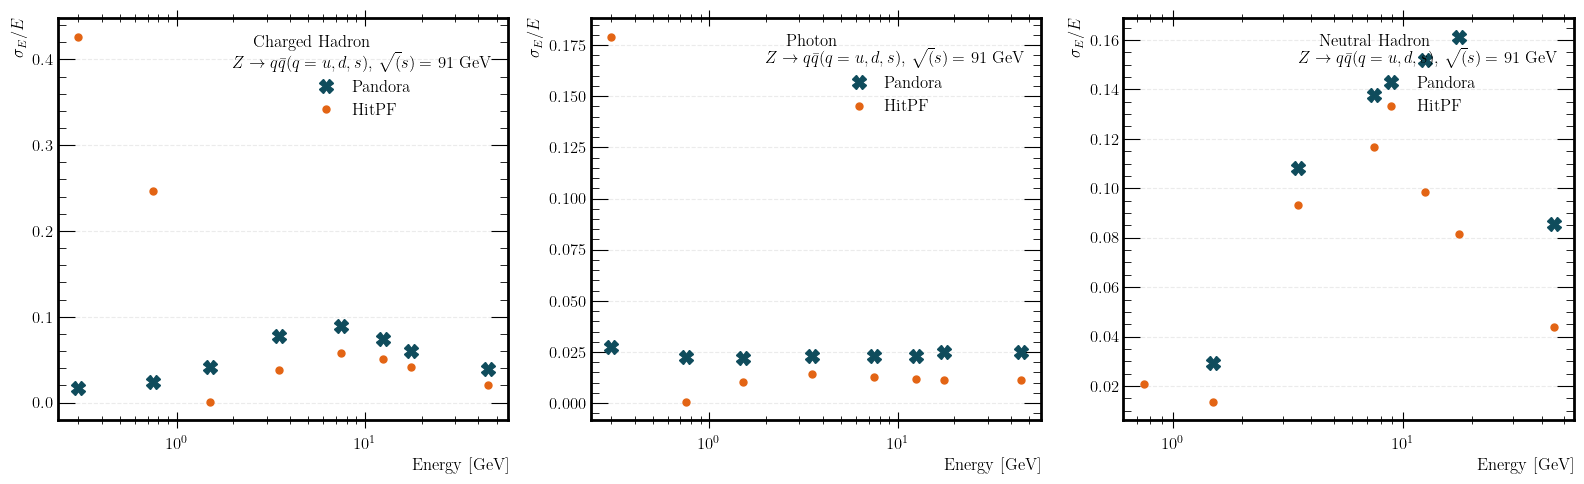

In [117]:
### E resolution with PID
photon_edir = photons_dic
ch_edir = hadrons_dic2
nh_edir = neutrons
plt.rc("text", usetex=True)
plt.rc("font", family="serif")

STYLE_OURS = dict(color="#E36414",  marker='.', linestyle='None', markersize=10) #lw=2.5, 
STYLE_PANDORA = dict(color="#0F4C5C" ,  marker='X', linestyle='None', markersize=10)
fig, ax_eff = plt.subplots(1, 3,figsize=(16, 5))
bins = [0, 5, 15, 50]
bin_labels = [f"[{bins[i]},{bins[i + 1]}]" for i in range(len(bins) - 1)]
ax_eff[1].plot(photon_edir["energy_resolutions_p"], np.array(photon_edir["varp_cld"]) / np.array(photon_edir["mp_cld"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[0].plot(photon_edir["energy_resolutions"], photon_edir["variance_om_baseline"] / photon_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[1].plot(photon_edir["energy_resolutions"],np.array(photon_edir["var_cld"]) / np.array(photon_edir["m_cld"]), label="HitPF", **STYLE_OURS)
ax_eff[1].set_xlabel("Energy [GeV]")
ax_eff[1].set_ylabel("$\sigma_E / E$")
ax_eff[1].set_xticks([2.5, 10.0, 33.0])
ax_eff[1].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[1].tick_params(axis='x', which='both', direction='inout')
ax_eff[1].legend(fontsize = size_font, title_fontsize=size_font, title=r"Photon \\ $Z\rightarrow q \bar q (q=u,d,s)$,  $\sqrt(s)=$ 91 GeV", loc="upper right")
ax_eff[0].plot(ch_edir["energy_resolutions_p"], np.array(ch_edir["varp_cld"]) / np.array(ch_edir["mp_cld"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[1].plot(ch_edir["energy_resolutions"], ch_edir["variance_om_baseline"] / ch_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[0].plot(ch_edir["energy_resolutions"],np.array(ch_edir["var_cld"])/ np.array(ch_edir["m_cld"]), label="HitPF", **STYLE_OURS)
ax_eff[0].set_xlabel("Energy [GeV]")
ax_eff[0].set_ylabel("$\sigma_E / E$")
ax_eff[0].set_xticks([2.5, 10.0, 33.0])
ax_eff[0].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[0].tick_params(axis='x', which='both', direction='inout')
ax_eff[0].legend(fontsize = size_font, title_fontsize=size_font, title=r"Charged Hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$,  $\sqrt(s)=$ 91 GeV", loc="upper right")


ax_eff[2].plot(nh_edir["energy_resolutions_p"], np.array(nh_edir["varp_cld"]) / np.array(nh_edir["mp_cld"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[2].plot(nh_edir["energy_resolutions"], nh_edir["variance_om_baseline"] / nh_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[2].plot(nh_edir["energy_resolutions"],np.array(nh_edir["var_cld"]) / np.array(nh_edir["m_cld"]), label="HitPF", **STYLE_OURS)
ax_eff[2].set_xlabel("Energy [GeV]")
ax_eff[2].set_ylabel("$\sigma_E / E$")
ax_eff[2].set_xticks([2.5, 10.0, 33.0])
ax_eff[2].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[2].tick_params(axis='x', which='both', direction='inout')
ax_eff[2].legend(fontsize = size_font, title_fontsize=size_font, title=r"Neutral Hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$,  $\sqrt(s)=$ 91 GeV", loc="upper right")

size_font  =12
for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    # ax.legend(fontsize = size_font)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)
    # ax.set_xlim([0.5,70])
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font
fig.tight_layout()
fig.savefig(os.path.join(PATH_store, "e_resolution_more_data_v05_reco.pdf"), bbox_inches="tight")


In [ ]:
### E resolution with PID
photon_edir = photons_dic
ch_edir = hadrons_dic2
nh_edir = neutrons
plt.rc("text", usetex=True)
plt.rc("font", family="serif")

STYLE_OURS = dict(color="#E36414",  marker='.', linestyle='None', markersize=10) #lw=2.5, 
STYLE_PANDORA = dict(color="#0F4C5C" ,  marker='X', linestyle='None', markersize=10)
fig, ax_eff = plt.subplots(1, 3,figsize=(16, 5))
bins = [0, 5, 15, 50]
bin_labels = [f"[{bins[i]},{bins[i + 1]}]" for i in range(len(bins) - 1)]
ax_eff[1].plot(photon_edir["energy_resolutions_p"], np.array(photon_edir["variance_om_p"]) / np.array(photon_edir["mean_p"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[0].plot(photon_edir["energy_resolutions"], photon_edir["variance_om_baseline"] / photon_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[1].plot(photon_edir["energy_resolutions"],np.array(photon_edir["variance_om"]) / np.array(photon_edir["mean"]), label="HitPF", **STYLE_OURS)
ax_eff[1].set_xlabel("Energy [GeV]")
ax_eff[1].set_ylabel("$\sigma_E / E$")
ax_eff[1].set_xticks([2.5, 10.0, 33.0])
ax_eff[1].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[1].tick_params(axis='x', which='both', direction='inout')
ax_eff[1].legend(fontsize = size_font, title_fontsize=size_font, title=r"Photon \\ $Z\rightarrow q \bar q (q=u,d,s)$,  $\sqrt(s)=$ 91 GeV", loc="upper right")
ax_eff[0].plot(ch_edir["energy_resolutions_p"], np.array(ch_edir["variance_om_p"]) / np.array(ch_edir["mean_p"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[1].plot(ch_edir["energy_resolutions"], ch_edir["variance_om_baseline"] / ch_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[0].plot(ch_edir["energy_resolutions"],np.array(ch_edir["variance_om"])/ np.array(ch_edir["mean"]), label="HitPF", **STYLE_OURS)
ax_eff[0].set_xlabel("Energy [GeV]")
ax_eff[0].set_ylabel("$\sigma_E / E$")
ax_eff[0].set_xticks([2.5, 10.0, 33.0])
ax_eff[0].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[0].tick_params(axis='x', which='both', direction='inout')
ax_eff[0].legend(fontsize = size_font, title_fontsize=size_font, title=r"Charged Hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$,  $\sqrt(s)=$ 91 GeV", loc="upper right")


ax_eff[2].plot(nh_edir["energy_resolutions_p"], np.array(nh_edir["variance_om_p"]) / np.array(nh_edir["mean_p"]), **STYLE_PANDORA,label="Pandora")
# ax_eff[2].plot(nh_edir["energy_resolutions"], nh_edir["variance_om_baseline"] / nh_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[2].plot(nh_edir["energy_resolutions"],np.array(nh_edir["variance_om"]) / np.array(nh_edir["mean"]), label="HitPF", **STYLE_OURS)
ax_eff[2].set_xlabel("Energy [GeV]")
ax_eff[2].set_ylabel("$\sigma_E / E$")
ax_eff[2].set_xticks([2.5, 10.0, 33.0])
ax_eff[2].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[2].tick_params(axis='x', which='both', direction='inout')
ax_eff[2].legend(fontsize = size_font, title_fontsize=size_font, title=r"Neutral Hadron\\ $Z\rightarrow q \bar q (q=u,d,s)$,  $\sqrt(s)=$ 91 GeV", loc="upper right")

size_font  =12
for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    # ax.legend(fontsize = size_font)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)
    # ax.set_xlim([0.5,70])
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font
fig.tight_layout()
fig.savefig(os.path.join(PATH_store, "e_resolution_more_data_v05.pdf"), bbox_inches="tight")

In [118]:
2/3000

0.0006666666666666666

In [56]:
tracks = True
# from src.utils.inference.per_particle_metrics import get_response_for_id_i
perfect_pid = False
mass_zero = False
pandora = True
ML_pid = True
matched_pandora = sd_pandora2[sd_pandora2.pid==22]
matched_ = sd_hgb2[sd_hgb2.pid==22]
matched_pandora_photon = matched_pandora[(matched_pandora.pandora_pid==22)] #*(matched_.pred_pid_matched==3)]
matched_photon = matched_[(matched_.pred_pid_matched==3)]#*(matched_pandora.pandora_pid==22)]
print("PID:22___________________________________________")
photons_dic2 = get_response_for_id_i(
    [22], matched_pandora_photon, matched_photon, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero,pandora=pandora, 
    ML_pid=ML_pid
)


PID:22___________________________________________
sum mask 0.1 2 3050
Using Pandora PID
sum mask 2 5 755
Using Pandora PID
sum mask 5 10 380
Using Pandora PID
sum mask 10 15 129
Using Pandora PID
sum mask 15 20 51
Using Pandora PID
sum mask 20 70 31
Using Pandora PID
sum mask 0.1 2 3398
sum mask 2 5 780
sum mask 5 10 400
sum mask 10 15 133
sum mask 15 20 53
sum mask 20 70 31


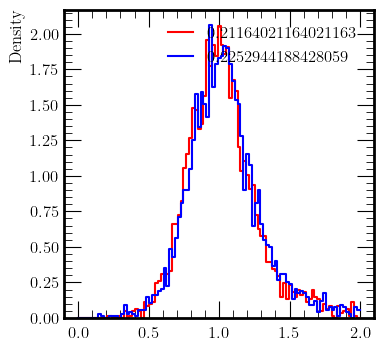

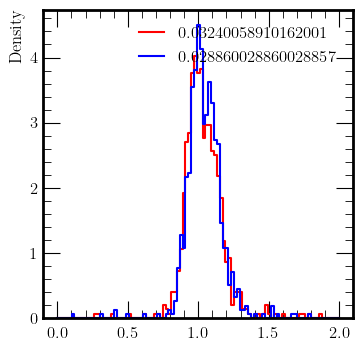

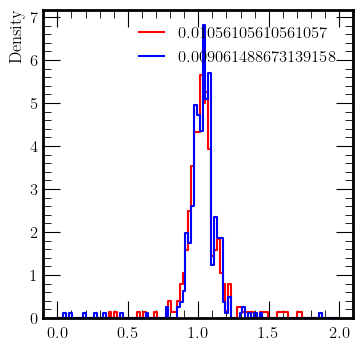

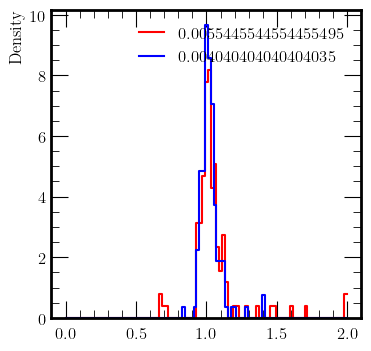

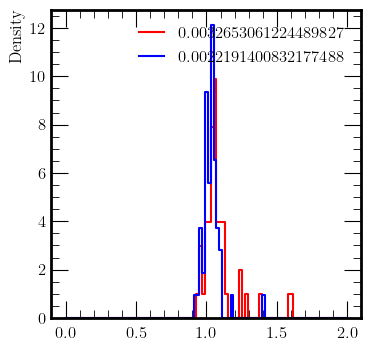

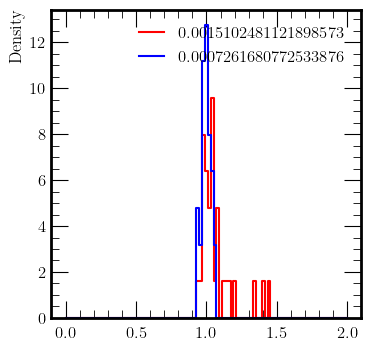

In [57]:
# number_binslen(np.exp(np.arange(np.log(0.5), np.log(60), 1)))
number_dist = len(photons_dic2["distributions_pandora"])
import seaborn as sns
for i in range(number_dist):
    vars_p = photons_dic2["variance_om_p"] / photons_dic2["energy_resolutions_p"]
    vars = photons_dic2["variance_om"] / photons_dic2["energy_resolutions"]
    fig = plt.figure(figsize=(4,4))
    sns.histplot(photons_dic2["distributions_pandora"][i], stat="density", bins= np.linspace(0, 2, 100), element="step", fill=False, color="red", label=str(vars_p[i]))
    sns.histplot(photons_dic2["distributions_model"][i], stat="density", bins= np.linspace(0, 2, 100), element="step", fill=False, color="blue", label=str(vars[i]))
    # photons_dic2["distributions_model"]
    plt.legend()
    PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
    PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")

    fig.savefig(os.path.join(PATH_store, "photons_"+str(i)+".pdf"), bbox_inches="tight")


In [58]:
print("PID:211___________________________________________")
# matched_pandora = sd_pandora2
# matched_ = sd_hgb2
matched_pandora = sd_pandora2[(np.abs(sd_pandora2.pid)==211)+(np.abs(sd_pandora2.pid)==2212)]
matched_ = sd_hgb2[(np.abs(sd_hgb2.pid)==211)+(np.abs(sd_hgb2.pid)==2212)]
matched_pandora_hadron= matched_pandora[(matched_pandora.pandora_pid==211)*(matched_.pred_pid_matched==1)]
matched_hadron = matched_[(matched_.pred_pid_matched==1)*(matched_pandora.pandora_pid==211)]
hadrons_dic2 = get_response_for_id_i(
    [211], matched_pandora_hadron, matched_hadron, tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid,pandora=pandora
)

# number_binslen(np.exp(np.arange(np.log(0.5), np.log(60), 1)))


PID:211___________________________________________
sum mask 0.1 2 263
Using Pandora PID
sum mask 2 5 287
Using Pandora PID
sum mask 5 10 231
Using Pandora PID
sum mask 10 15 113
Using Pandora PID


/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/inference_metrics.py:167: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  MPV, std68 = torch.mean(torch.tensor(data_for_hist)).item(), torch.std(torch.tensor(data_for_hist)).item()


sum mask 15 20 57
Using Pandora PID
sum mask 20 70 48
Using Pandora PID
sum mask 0.1 2 263
sum mask 2 5 287
sum mask 5 10 231
sum mask 10 15 113
sum mask 15 20 57
sum mask 20 70 48


In [16]:
from src.utils.inference.inference_metrics import get_std68
def obtain_MPV_and_68(data_for_hist, bins_per_binned_E, epsilon=0.01, no_divide=False):
    hist, bin_edges = np.histogram(data_for_hist, bins=bins_per_binned_E, density=True)
    ind_max_hist = np.argmax(hist)
    MPV = (bin_edges[ind_max_hist] + bin_edges[ind_max_hist + 1]) / 2
    std68, low, high = get_std68(hist, bin_edges, epsilon=epsilon)
    print("std", std68, low, high)
    if std68 == 0.4 and low == 0.2 and high == 1.0:
        print("not able to use tsd68")
        # It didn't fit correctly as it's too close to a delta function
        if type(data_for_hist) == pd.Series:
            data_for_hist = data_for_hist.values
        MPV, std68 = torch.mean(torch.tensor(data_for_hist)).item(), torch.std(torch.tensor(data_for_hist)).item()
    if no_divide:
        return MPV, std68
    return MPV, std68 / MPV

In [78]:
from src.utils.inference.inference_metrics import get_std68
print(obtain_MPV_and_68(hadrons_dic2["distributions_pandora"][1],  np.linspace(0, 2, 200)))
print(obtain_MPV_and_68(hadrons_dic2["distributions_model"][1],  np.linspace(0, 2, 200)))

(1.0, 0.01005025125628134)
here
(1.023300051689148, 0.059563690148825794)


In [61]:
print(hadrons_dic2["variance_om_p"])
print(hadrons_dic2["energy_resolutions_p"])
print(hadrons_dic2["variance_om"])
print(hadrons_dic2["energy_resolutions"])

[0.20212168820448895, 0.13683530132873428, 0.01569880009529789, 0.07870772259851391, 0.014132509228381045, 0.034912441057785785]
[ 1.05  3.5   7.5  12.5  17.5  45.  ]
[0.07070707070707072, 0.059563690148825794, 0.046655270787501195, 0.055196977980498906, 0.010610660451219976, 0.012092733310888455]
[ 1.05  3.5   7.5  12.5  17.5  45.  ]


6


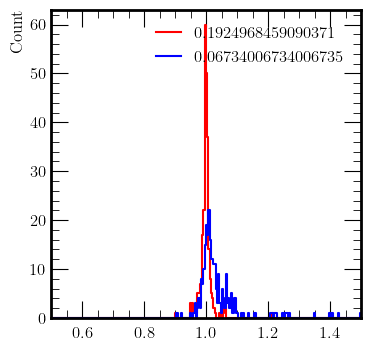

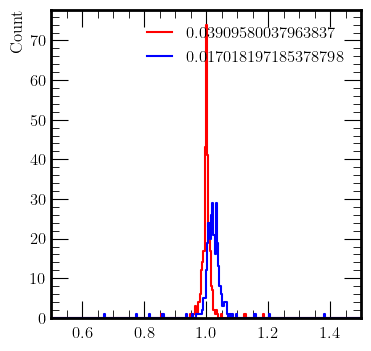

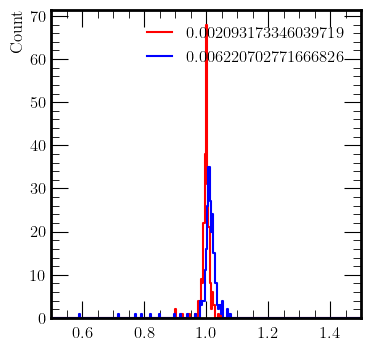

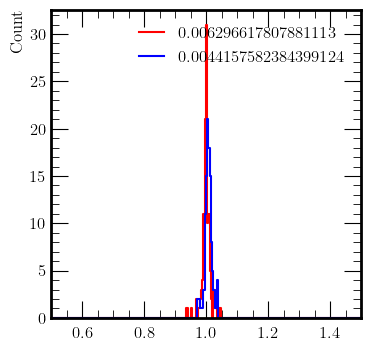

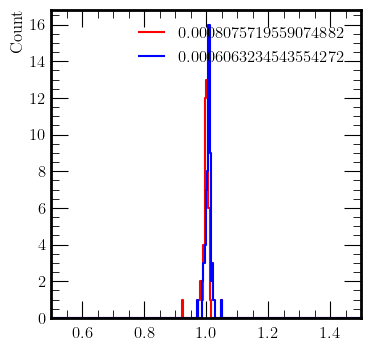

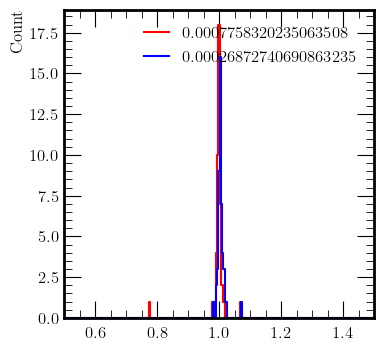

In [60]:
number_dist = len(hadrons_dic2["distributions_pandora"])
print(number_dist)
import seaborn as sns
for i in range(number_dist):
    vars_p = hadrons_dic2["variance_om_p"] / hadrons_dic2["energy_resolutions_p"]
    vars = hadrons_dic2["variance_om"] / hadrons_dic2["energy_resolutions"]
    fig = plt.figure(figsize=(4,4))
    sns.histplot(hadrons_dic2["distributions_pandora"][i], bins= np.linspace(0, 2, 500), stats="density", element="step", fill=False, color="red", label=str(vars_p[i]))
    sns.histplot(hadrons_dic2["distributions_model"][i],bins= np.linspace(0, 2, 500), stats="density",element="step", fill=False, color="blue", label=str(vars[i]))
    plt.xlim([0.5,1.5])
    # photons_dic2["distributions_model"]
    plt.legend()
    PATH_store = os.path.join("/eos/user/m/mgarciam/datasets_mlpf/models_trained_CLD/041225_arc_05/", "paper_plots")
    PATH_store_summary_plots = os.path.join(PATH_store, "summary_plots")

    fig.savefig(os.path.join(PATH_store, "hadrons_"+str(i)+".png"), bbox_inches="tight")

In [41]:
print("PID:neutron___________________________________________")
neutrons2 = get_response_for_id_i(
    [2112], matched_pandora[np.abs(matched_pandora.pandora_pid)==2112], matched_[matched_.pred_pid_matched==2], tracks=tracks, perfect_pid=perfect_pid, mass_zero=mass_zero, ML_pid=ML_pid,pandora=pandora
)

PID:neutron___________________________________________
sum mask 0.5 1.3591409142295225 17
Using Pandora PID


/tmp/mgarciam/ipykernel_2075418/1890223705.py:69: RuntimeWarning: invalid value encountered in sqrt
  pred_pxyz = np.sqrt(p_squared).reshape(-1, 1) * pred_pxyz
/afs/cern.ch/work/m/mgarciam/private/mlpf/src/utils/inference/inference_metrics.py:167: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  MPV, std68 = torch.mean(torch.tensor(data_for_hist)).item(), torch.std(torch.tensor(data_for_hist)).item()


sum mask 1.3591409142295225 3.6945280494653248 64
Using Pandora PID
sum mask 3.6945280494653248 10.042768461593832 58
Using Pandora PID
sum mask 10.042768461593832 27.299075016572118 45
Using Pandora PID
sum mask 0.5 1.3591409142295225 30
sum mask 1.3591409142295225 3.6945280494653248 73
sum mask 3.6945280494653248 10.042768461593832 69
sum mask 10.042768461593832 27.299075016572118 55


In [27]:
### E resolution with PID
photon_edir = photons_dic2
ch_edir = hadrons_dic2
nh_edir = neutrons2
plt.rc("text", usetex=True)
plt.rc("font", family="serif")
colors_list = ["#0F4C5C", "#E36414", "#E36414"]
STYLE_OURS = dict(color="#0F4C5C",  marker='.', linestyle='None', markersize=10) #lw=2.5, 
STYLE_PANDORA = dict(color="#E36414",  marker='s', linestyle='None', markersize=10)
fig, ax_eff = plt.subplots(1, 3,figsize=(16, 5))
bins = [0, 5, 15, 50]
bin_labels = [f"[{bins[i]},{bins[i + 1]}]" for i in range(len(bins) - 1)]
ax_eff[1].plot(photon_edir["energy_resolutions_p"], photon_edir["variance_om_p"] / photon_edir["energy_resolutions_p"], **STYLE_PANDORA,label="Pandora")
# ax_eff[0].plot(photon_edir["energy_resolutions"], photon_edir["variance_om_baseline"] / photon_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[1].plot(photon_edir["energy_resolutions"],photon_edir["variance_om"] / photon_edir["energy_resolutions"], label="HitPF", **STYLE_OURS)
ax_eff[1].set_xlabel("Energy [GeV]")
# ax_eff[0].set_title(r"$\gamma$")
ax_eff[1].set_ylabel("$\sigma_E / E$")
ax_eff[1].set_xticks([2.5, 10.0, 33.0])
ax_eff[1].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[1].tick_params(axis='x', which='both', direction='inout')
ax_eff[1].legend(fontsize = size_font, title_fontsize=size_font, title=r"$\gamma$, $Z\rightarrow q \bar q (q=u,d,s)$, $\sqrt(s)=$ 91 GeV", loc="lower right")

ax_eff[0].plot(ch_edir["energy_resolutions_p"], ch_edir["variance_om_p"] / ch_edir["energy_resolutions_p"], **STYLE_PANDORA,label="Pandora")
# ax_eff[1].plot(ch_edir["energy_resolutions"], ch_edir["variance_om_baseline"] / ch_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[0].plot(ch_edir["energy_resolutions"],ch_edir["variance_om"] / ch_edir["energy_resolutions"], label="HitPF", **STYLE_OURS)
ax_eff[0].set_xlabel("Energy [GeV]")
ax_eff[0].set_title("Charged Hadrons")
ax_eff[0].set_ylabel("$\sigma_E / E$")
ax_eff[0].set_xticks([2.5, 10.0, 33.0])
ax_eff[0].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[0].tick_params(axis='x', which='both', direction='inout')
ax_eff[0].legend(fontsize = size_font, title_fontsize=size_font, title=r"Charged Hadrons, \n $Z\rightarrow q \bar q (q=u,d,s)$, $\sqrt(s)=$ 91 GeV", loc="lower right")


ax_eff[2].plot(nh_edir["energy_resolutions_p"], nh_edir["variance_om_p"] / nh_edir["energy_resolutions_p"], **STYLE_PANDORA,label="Pandora")
# ax_eff[2].plot(nh_edir["energy_resolutions"], nh_edir["variance_om_baseline"] / nh_edir["energy_resolutions"], ".--", c="k", label="Baseline")

ax_eff[2].plot(nh_edir["energy_resolutions"],nh_edir["variance_om"] / nh_edir["energy_resolutions"], label="HitPF", **STYLE_OURS)
ax_eff[2].set_xlabel("Energy [GeV]")
ax_eff[2].set_title("Neutral Hadrons")
ax_eff[2].set_ylabel("$\sigma_E / E$")
ax_eff[2].set_xticks([2.5, 10.0, 33.0])
ax_eff[2].set_xticklabels(bin_labels, fontsize=10)  # Set the corresponding bin range labels
ax_eff[2].tick_params(axis='x', which='both', direction='inout')
size_font  =12
for ax in ax_eff.flatten():
    ax.grid(True, axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)
    ax.legend(fontsize = size_font)
    ax.set_xscale("log")
    ax.tick_params(axis='both', which='major', labelsize=size_font)
    ax.tick_params(axis='both', which='minor', labelsize=size_font)
    # ax.set_xlim([0.2,70])
plt.rcParams['text.usetex'] = True
plt.rcParams['font.size'] = size_font
plt.rcParams['axes.labelsize'] = size_font
plt.rcParams['xtick.labelsize'] = size_font
plt.rcParams['ytick.labelsize'] = size_font
plt.rcParams['legend.fontsize'] = size_font
fig.tight_layout()
fig.savefig(os.path.join(PATH_store, "e_resolution_epid_all_v05.pdf"), bbox_inches="tight")

NameError: name 'photons_dic2' is not defined